In [1]:
# Useful for debugging
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import scipy.constants as spc
import subprocess
import os, re
from skopt import gp_minimize
from skopt.space import Real
from scipy.optimize import OptimizeResult
from skopt.plots import *
from functools import partial
import pandas as pd
import pickle
import multiprocessing as mp

In [3]:
# Nicer plotting
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12,8)
%config InlineBackend.figure_format = 'retina'

In [4]:
from astra import Astra
# load astra and generator binaries
%env ASTRA_BIN=/home/cspark/Work/simulation_codes-working/lume-astra/bin/astra
%env GENERATOR_BIN=/home/cspark/Work/simulation_codes-working/lume-astra/bin/generator
!echo $ASTRA_BIN
!echo $GENERATOR_BIN

env: ASTRA_BIN=/home/cspark/Work/simulation_codes-working/lume-astra/bin/astra
env: GENERATOR_BIN=/home/cspark/Work/simulation_codes-working/lume-astra/bin/generator
/home/cspark/Work/simulation_codes-working/lume-astra/bin/astra
/home/cspark/Work/simulation_codes-working/lume-astra/bin/generator


In [5]:
def astra_simulation(parameters, weights):
    # Create an Astra object
    astra_sim = Astra('astra.in')
    astra_sim.timeout = None
    astra_sim.verbose = False

    print ("parameters:", parameters)
    # Set up Astra parameters by modifying the input file or setting the attributes in the object
    astra_sim['solenoid:maxb(1)'] = parameters[0]           # solenoid strength [T]
    astra_sim['quadrupole:q_grad(1)'] = parameters[1]        # quadrupole strength [1/m^2]
    astra_sim['quadrupole:q_grad(2)'] = parameters[2]        # quadrupole strength [1/m^2]
    astra_sim['cavity:phi(1)'] = parameters[3]              # RF gun cavity input phase [deg]
    astra_sim['cavity:phi(2)'] = parameters[4]              # ACC1 cavity input phase [deg]
    astra_sim['cavity:phi(3)'] = parameters[4]              # ACC2 cavity input phase [deg]
    astra_sim['cavity:phi(4)'] = parameters[5]              # ACC3 cavity input phase [deg]
    astra_sim['cavity:phi(5)'] = parameters[5]              # ACC4 cavity input phase [deg]

    # Run the Astra simulation
    astra_sim.run()

    # Extract results from the simulation
    norm_emit_x = astra_sim.output['stats']['norm_emit_x'][-1]
    norm_emit_y = astra_sim.output['stats']['norm_emit_y'][-1]
    sigma_energy = astra_sim.output['stats']['sigma_energy'][-1]

    print ("objectives:", norm_emit_x, norm_emit_y, sigma_energy, "\n")

    target_norm_emit = 10e-9
    target_energy_spread = 0.005

    norm_emit0 = target_norm_emit * bg
    sigma_energy0 = 200.19e6 * target_energy_spread

    # weights
    w1, w2, w3 = weights
    
    # Objective: Minimize the sum of horizontal emittance, vertical emittance, and energy spread
    objectives = (w1 * norm_emit_x + w2 * norm_emit_y) / norm_emit0 + w3 * sigma_energy / sigma_energy0

    return objectives

In [6]:
def get_weights_from_filename(filename):
    """
    Extracts the list of weights from a filename generated by the optimization script.

    Args:
        filename (str): The full filename, e.g., 'data/optimization_results_0p05_0p05_0p9.csv'.

    Returns:
        list: A list of floats representing the weights.
    """
    # Define a pattern to find the weight part of the filename
    # This looks for any file that starts with "gp_minimize_result_" or "optimization_results_"
    # and ends with a file extension like .pkl or .csv
    pattern = r'(?:gp_minimize_result_|optimization_results_)(.*)\.(?:pkl|csv)'

    match = re.search(pattern, os.path.basename(filename))
    
    if match:
        weights_string = match.group(1)
        # Replace 'p' with '.' and split the string by underscores
        weight_parts = weights_string.replace('p', '.').split('_')
        
        # Convert each string part to a float and return as a list
        try:
            weights = [float(w) for w in weight_parts]
            return weights
        except ValueError:
            print(f"Error: Could not convert weight parts to floats: {weight_parts}")
            return None
    else:
        print(f"Error: Filename format not recognized: {filename}")
        return None

In [7]:
weight_combinations = [
    [0.05, 0.05, 0.9],
    [0.1, 0.1, 0.8],
    [0.15, 0.15, 0.7],
    [0.2, 0.2, 0.6],
    [0.25, 0.25, 0.5],
    [0.3, 0.3, 0.4],
    [0.35, 0.35, 0.3],
    [0.4, 0.4, 0.2],
    [0.45, 0.45, 0.1],
]

In [8]:
bg = 392.76205690637397 * 0.9999967587565166
print ("beta * gamma:", bg)

beta * gamma: 392.7607838689165


In [9]:
n = 3

weights = weight_combinations[n]
filename_weights = "_".join(map(lambda x: str(x).replace('.', 'p'), weights))
pickle_filename = f'data/gp_minimize_result_{filename_weights}.pkl'
csv_filename = f'data/optimization_results_{filename_weights}.csv'

output_filename = f'results/output_{filename_weights}.pkl'

with open(pickle_filename, 'rb') as f:
    result = pickle.load(f)
    
df_results = pd.read_csv(csv_filename)

min_index = np.argmin(result.func_vals)
print(min_index, result.func_vals[min_index])

86 1.0451298232896922


In [10]:
with open(output_filename, 'rb') as f:
    loaded_output_list = pickle.load(f)

In [11]:
norm_emit_x = [stats['norm_emit_x'][-1] for stats in loaded_output_list]
norm_emit_y = [stats['norm_emit_y'][-1] for stats in loaded_output_list]
sigma_energy = [stats['sigma_energy'][-1] for stats in loaded_output_list]

sigma_x = [stats['sigma_x'][-1] for stats in loaded_output_list]
sigma_xp = [stats['sigma_xp'][-1] for stats in loaded_output_list]
sigma_y = [stats['sigma_y'][-1] for stats in loaded_output_list]
sigma_yp = [stats['sigma_yp'][-1] for stats in loaded_output_list]
sigma_z = [stats['sigma_z'][-1] for stats in loaded_output_list]
mean_kinetic_energy = [stats['mean_kinetic_energy'][-1] for stats in loaded_output_list]

In [17]:
def plot_objective_space(min_index):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs = axs.flatten()

    #for i in range(0, 100):
    #    axs[0].scatter(nex[i]*1e6, ney[i]*1e6, marker='*', s=2)
    axs[0].scatter([x*1e6 for x in norm_emit_x], [x*1e6 for x in norm_emit_y], c='b', marker='o', s=2)
    axs[0].scatter(norm_emit_x[min_index]*1e6, norm_emit_y[min_index]*1e6, c='r', marker='o', label='Best')
    axs[0].set_xlabel(r'$\epsilon_{n, x}$ [mm-mrad]')
    axs[0].set_ylabel(r'$\epsilon_{n, y}$ [mm-mrad]')
    axs[0].set_title(r'$\epsilon_{n, x}$ vs. $\epsilon_{n, y}$')
    axs[0].grid(True)
    axs[0].legend(loc='best')

    axs[1].scatter([x/200e6 for x in sigma_energy], [x*1e6 for x in norm_emit_x], c='b', marker='o', s=2)
    axs[1].scatter(sigma_energy[min_index]/200e6, norm_emit_x[min_index]*1e6, c='r', marker='o', label='Best')
    axs[1].set_xlabel(r'$\Delta E/E$')
    axs[1].set_ylabel(r'$\epsilon_{n, x}$ [mm-mrad]')
    axs[1].set_title(r'$\Delta E/E$ vs. $\epsilon_{n, x}$')
    axs[1].grid(True)
    axs[1].legend(loc='best')

    axs[2].scatter([x/200e6 for x in sigma_energy], [x*1e6 for x in norm_emit_y], c='b', marker='o', s=2)
    axs[2].scatter(sigma_energy[min_index]/200e6, norm_emit_y[min_index]*1e6, c='r', marker='o', label='Best')
    axs[2].set_xlabel(r'$\Delta E/E$')
    axs[2].set_ylabel(r'$\epsilon_{n, y}$ [mm-mrad]')
    axs[2].set_title(r'$\Delta E/E$ vs. $\epsilon_{n, y}$')
    axs[2].grid(True)
    axs[2].legend(loc='best')

    plt.tight_layout()
    plt.savefig("img/objective_space.png")
    plt.show()

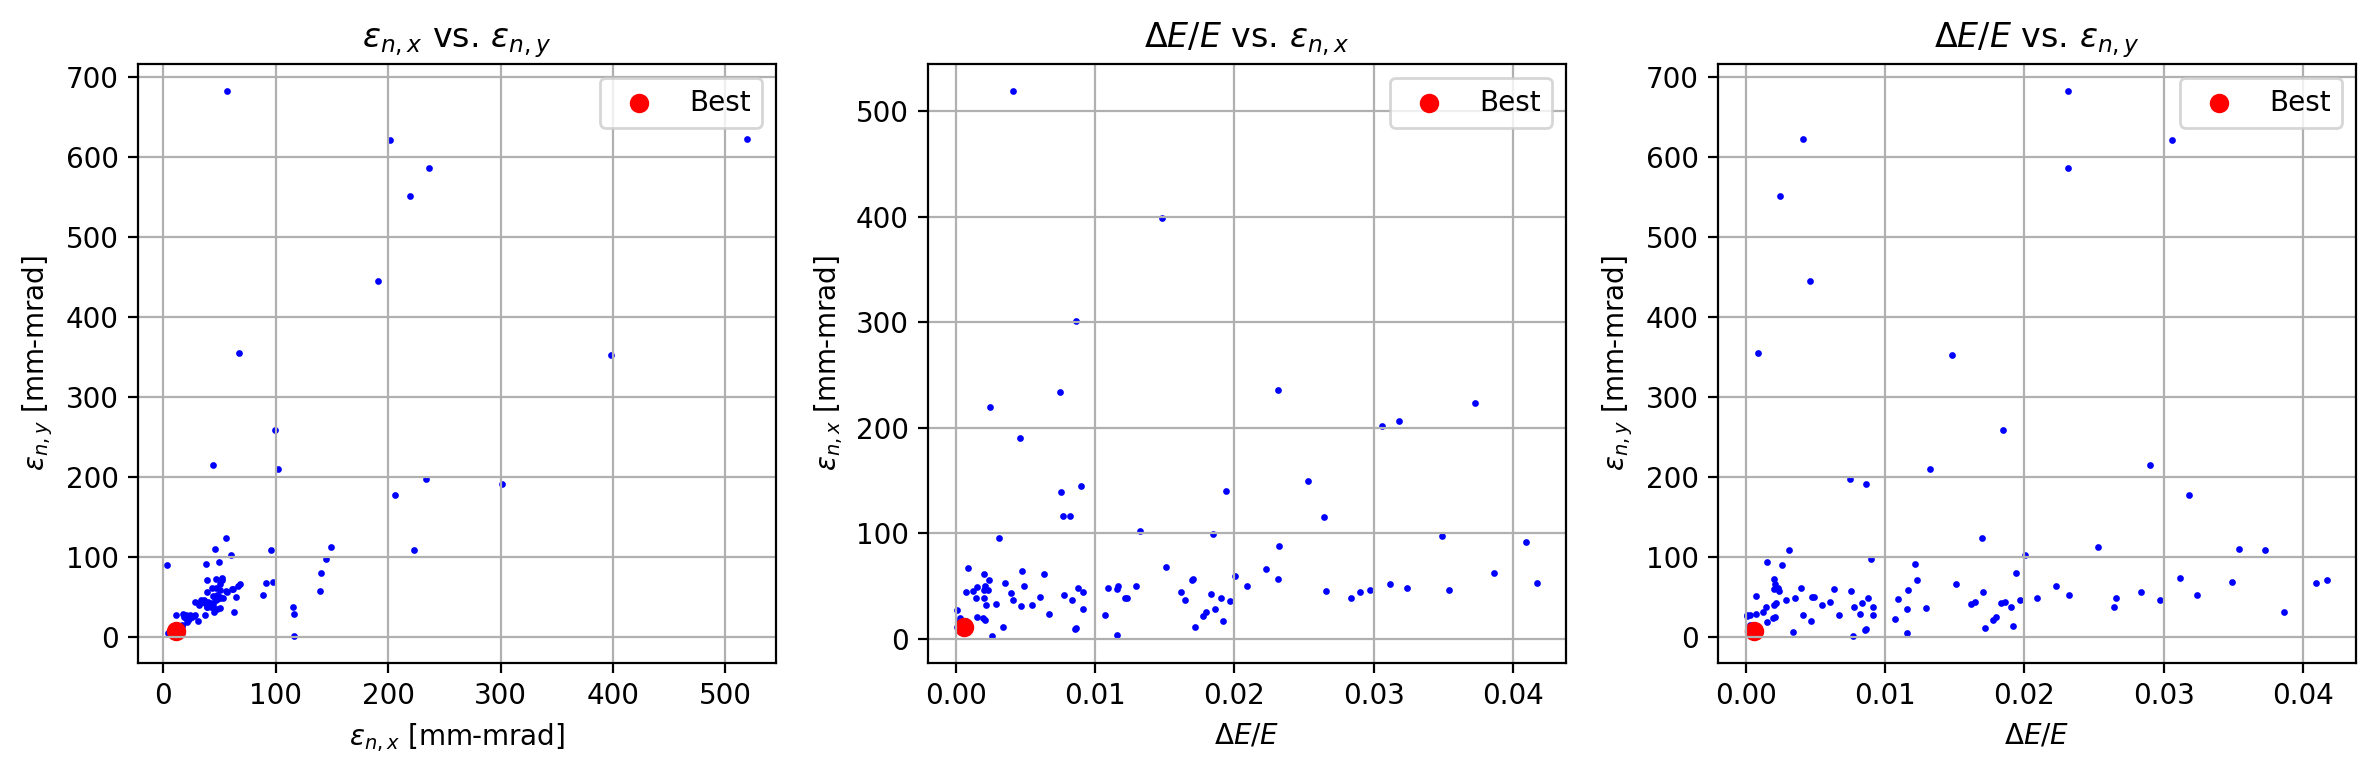

In [18]:
plot_objective_space(min_index)

In [19]:
def plot_constraint_space(min_index):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs = axs.flatten()

    axs[0].scatter([x*1e3 for x in sigma_x], [x*1e3 for x in sigma_xp], c='b', marker='o', s=2)
    axs[0].scatter(sigma_x[min_index]*1e3, sigma_xp[min_index]*1e3, c='r', marker='o', label='Best')
    axs[0].axvline(0.3, color='purple', linestyle='--')
    axs[0].axhline(0.3, color='purple', linestyle='--')
    axs[0].set_xlabel(r'$\sigma_x$ [mm]')
    axs[0].set_ylabel(r'$\sigma_{x^{\prime}}$ [mrad]')
    axs[0].set_title(r'$\sigma_x$ vs. $\sigma_{x^{\prime}}$')
    axs[0].grid(True)
    axs[0].legend(loc='best')

    axs[1].scatter([x*1e3 for x in sigma_y], [x*1e3 for x in sigma_yp], c='b', marker='o', s=2)
    axs[1].scatter(sigma_y[min_index]*1e3, sigma_yp[min_index]*1e3, c='r', marker='o', label='Best')
    axs[1].axvline(0.3, color='purple', linestyle='--')
    axs[1].axhline(0.3, color='purple', linestyle='--')
    axs[1].set_xlabel(r'$\sigma_y$ [mm]')
    axs[1].set_ylabel(r'$\sigma_{y^{\prime}}$ [mrad]')
    axs[1].set_title(r'$\sigma_y$ vs. $\sigma_{y^{\prime}}$')
    axs[1].grid(True)
    axs[1].legend(loc='best')

    axs[2].scatter([x*1e3 for x in sigma_z], [x/1e6 for x in mean_kinetic_energy], c='b', marker='o', s=2)
    axs[2].scatter(sigma_z[min_index]*1e3, mean_kinetic_energy[min_index]/1e6, c='r', marker='o', label='Best')
    axs[2].axvline(1.0, color='purple', linestyle='--')
    axs[2].axhline(205, color='purple', linestyle='--')
    axs[2].axhline(195, color='purple', linestyle='--')
    axs[2].set_xlabel(r'$\sigma_z$ [mm]')
    axs[2].set_ylabel(r'$<E>$ [MeV]')
    axs[2].set_title(r'$\sigma_z$ vs. $<E>$')
    axs[2].grid(True)
    axs[2].legend(loc='best')
    
    plt.tight_layout()
    plt.savefig("img/constraint_space.png")
    plt.show()

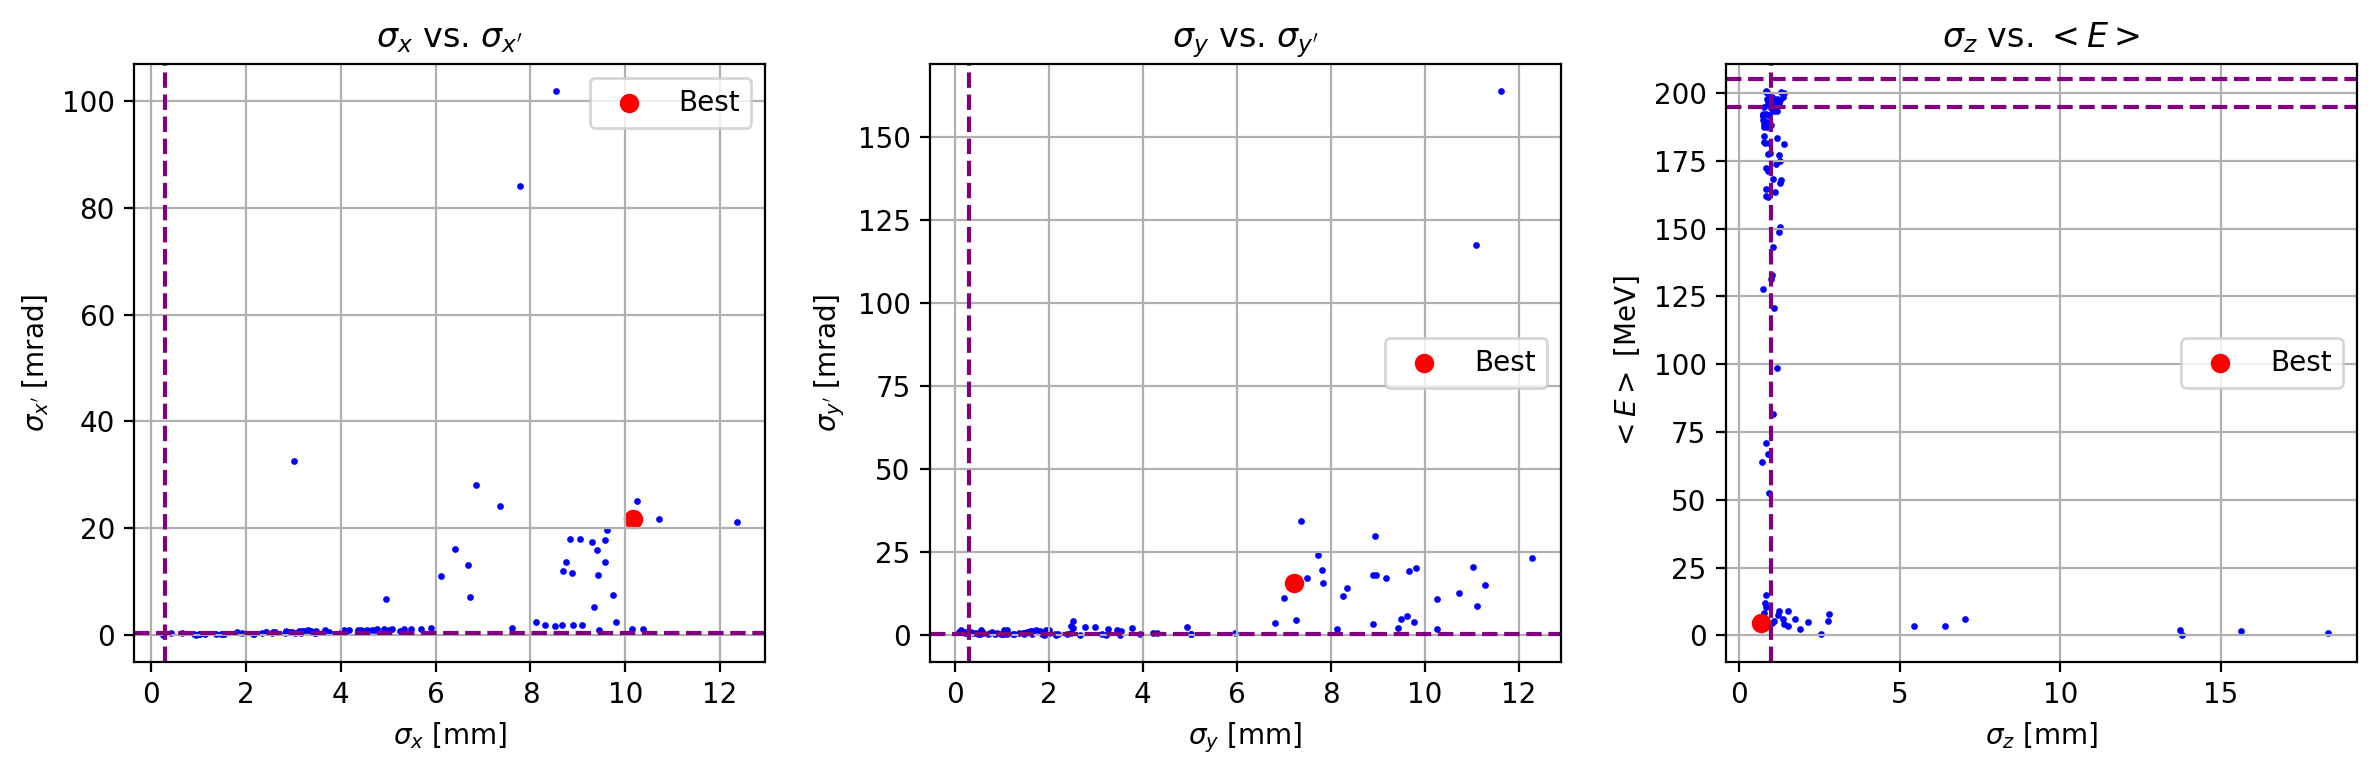

In [20]:
plot_constraint_space(min_index)

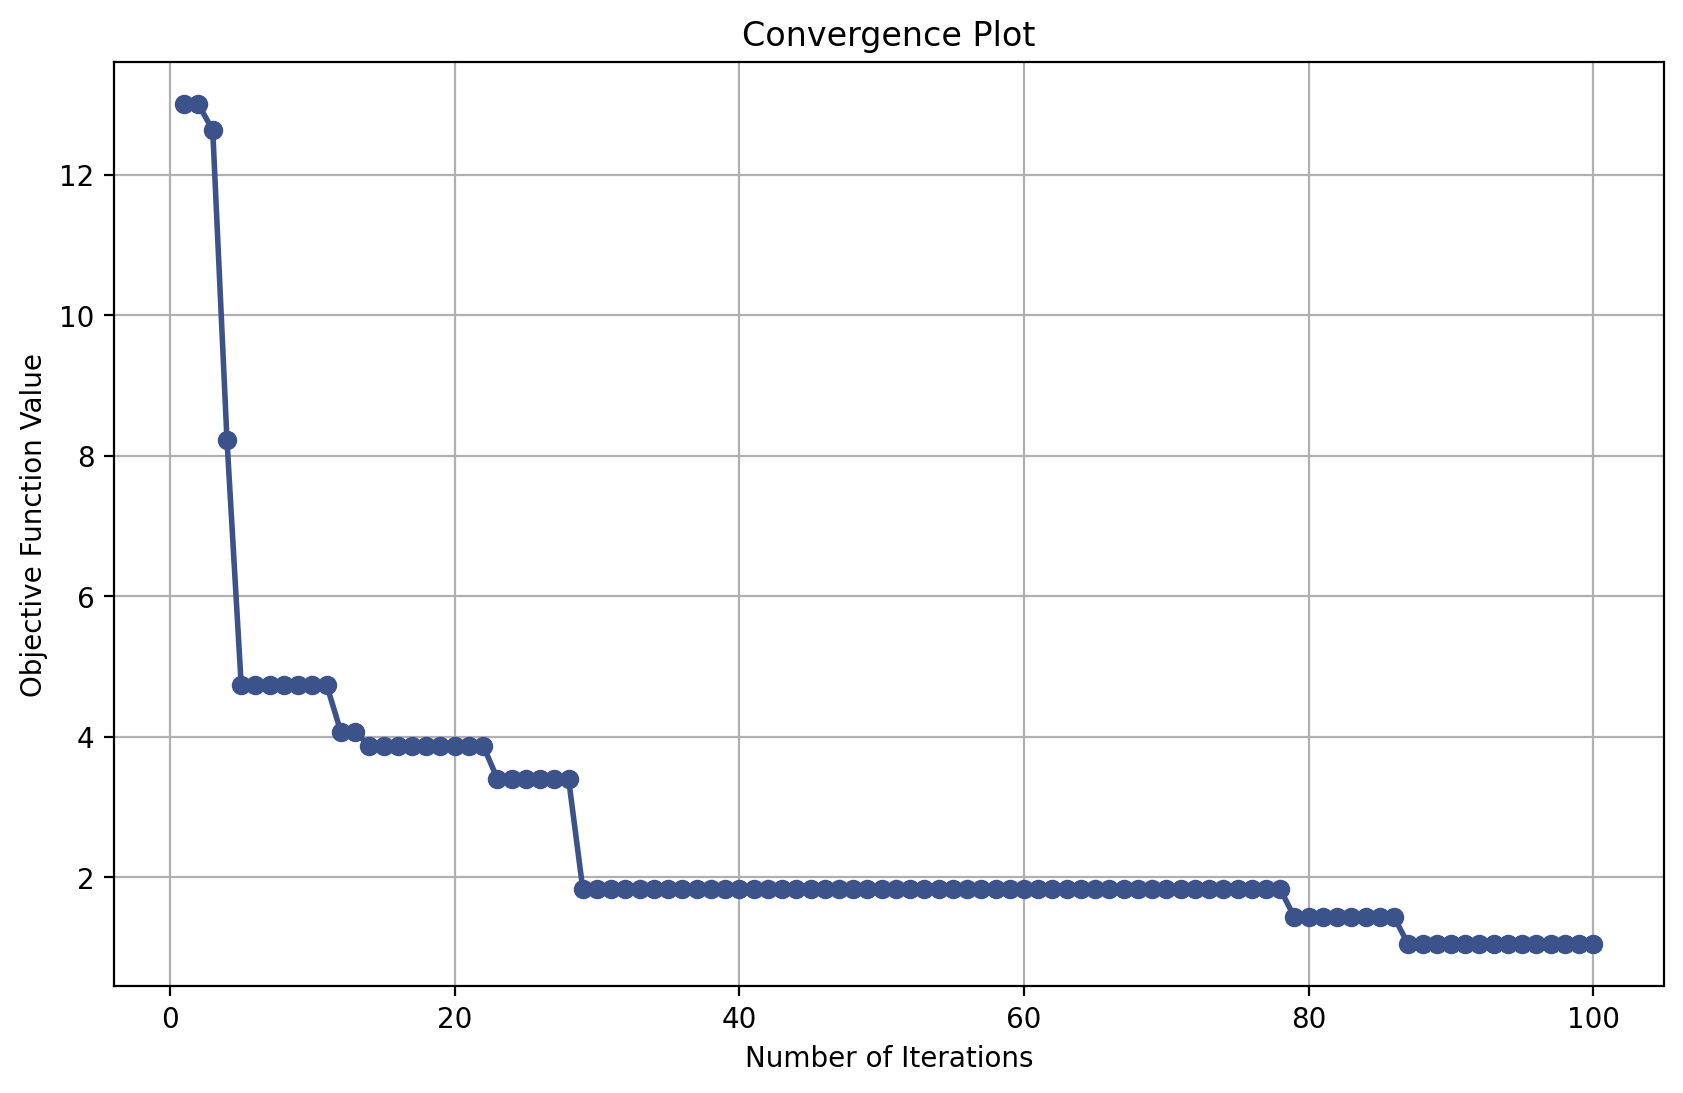

<Figure size 1000x800 with 0 Axes>

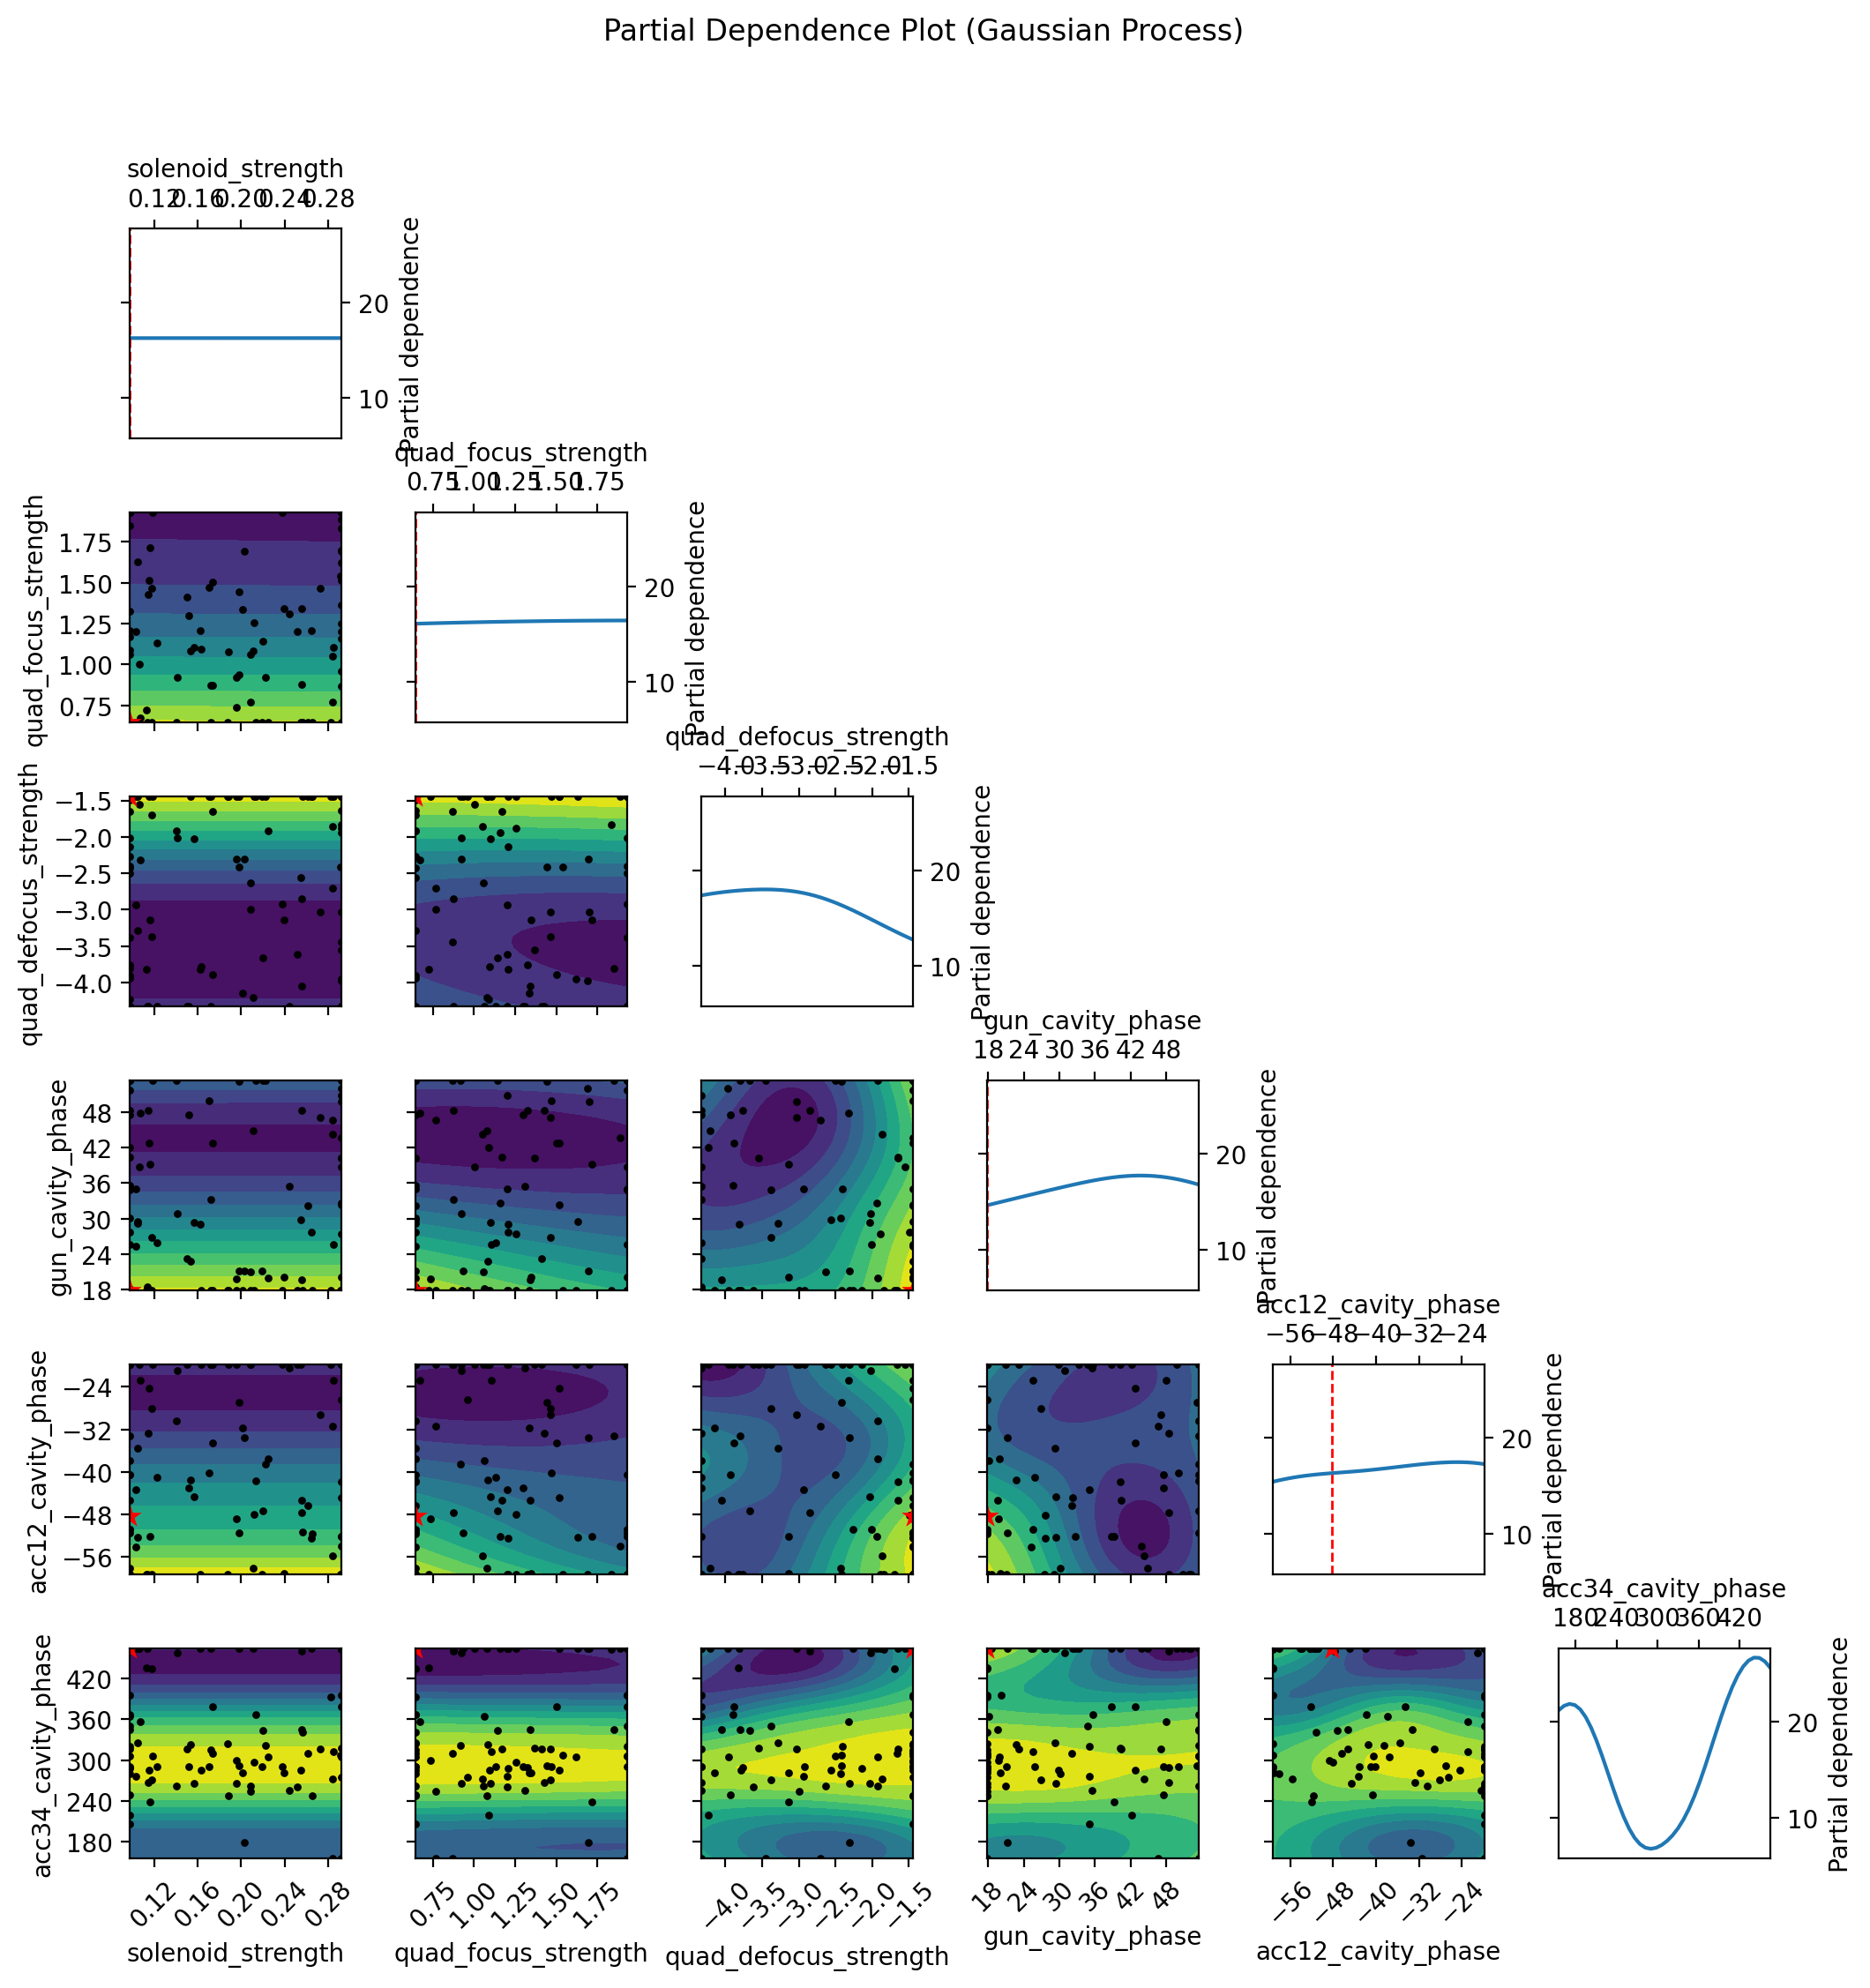

<Figure size 1000x800 with 0 Axes>

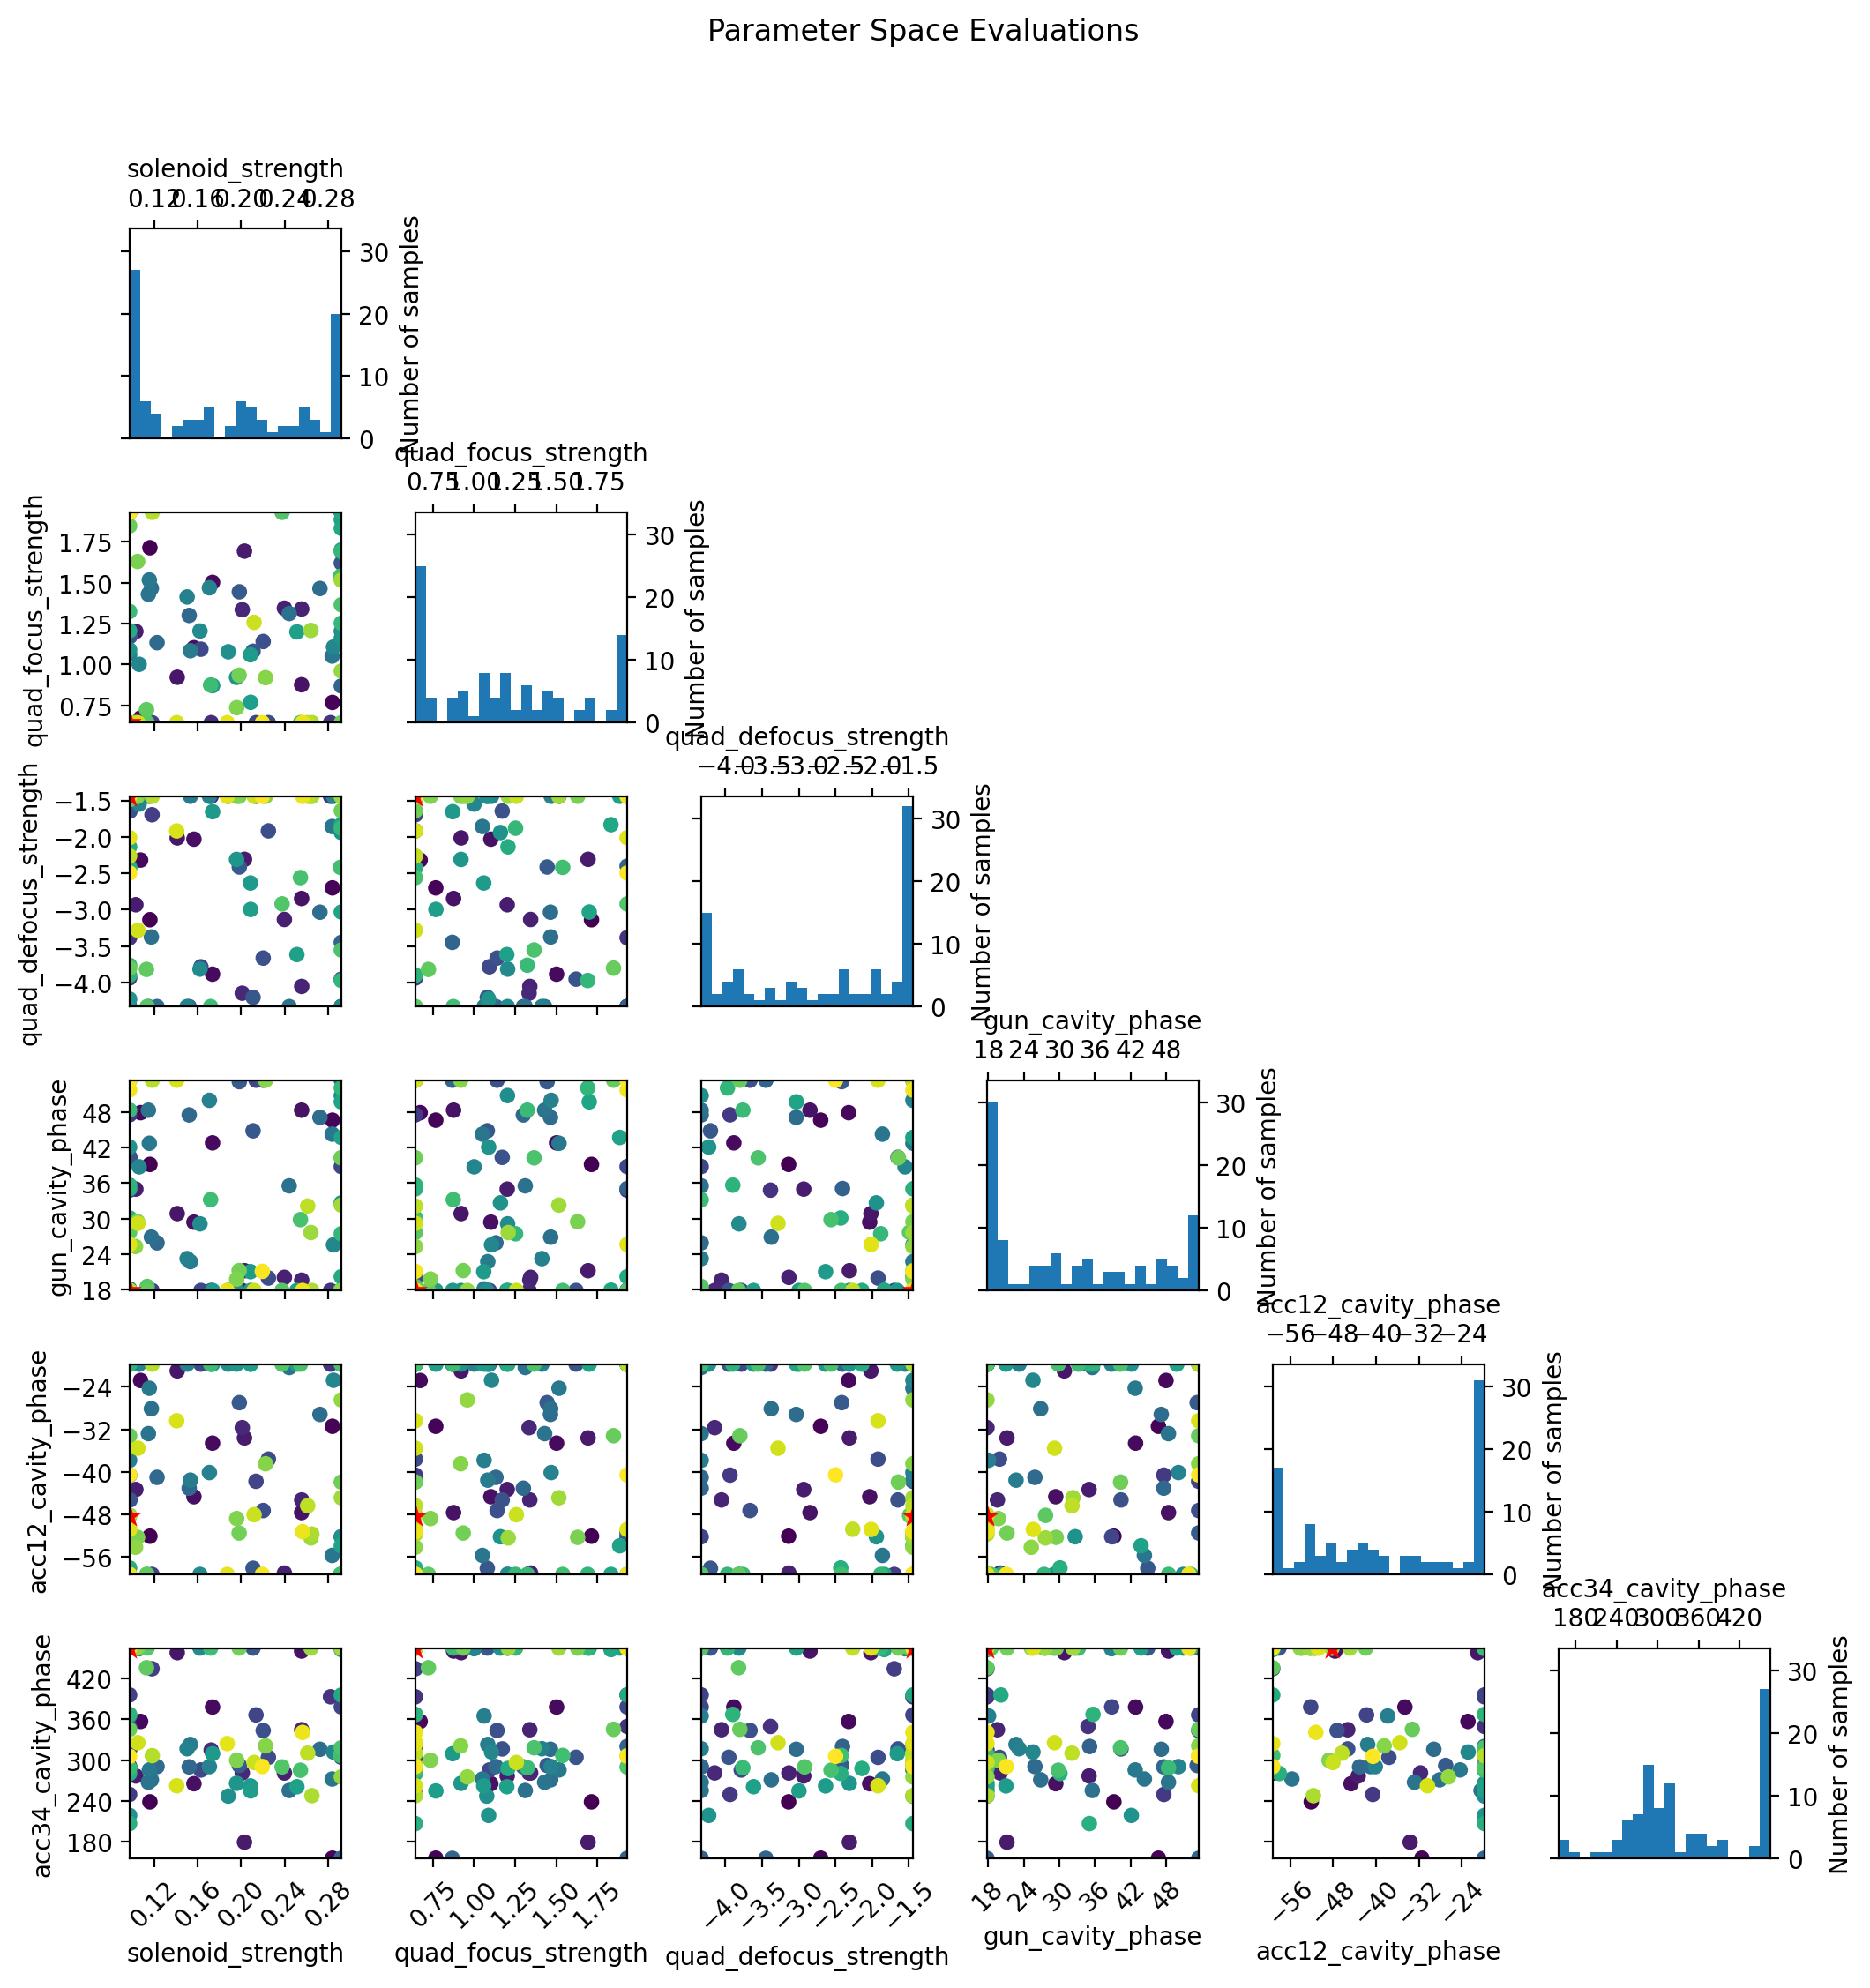

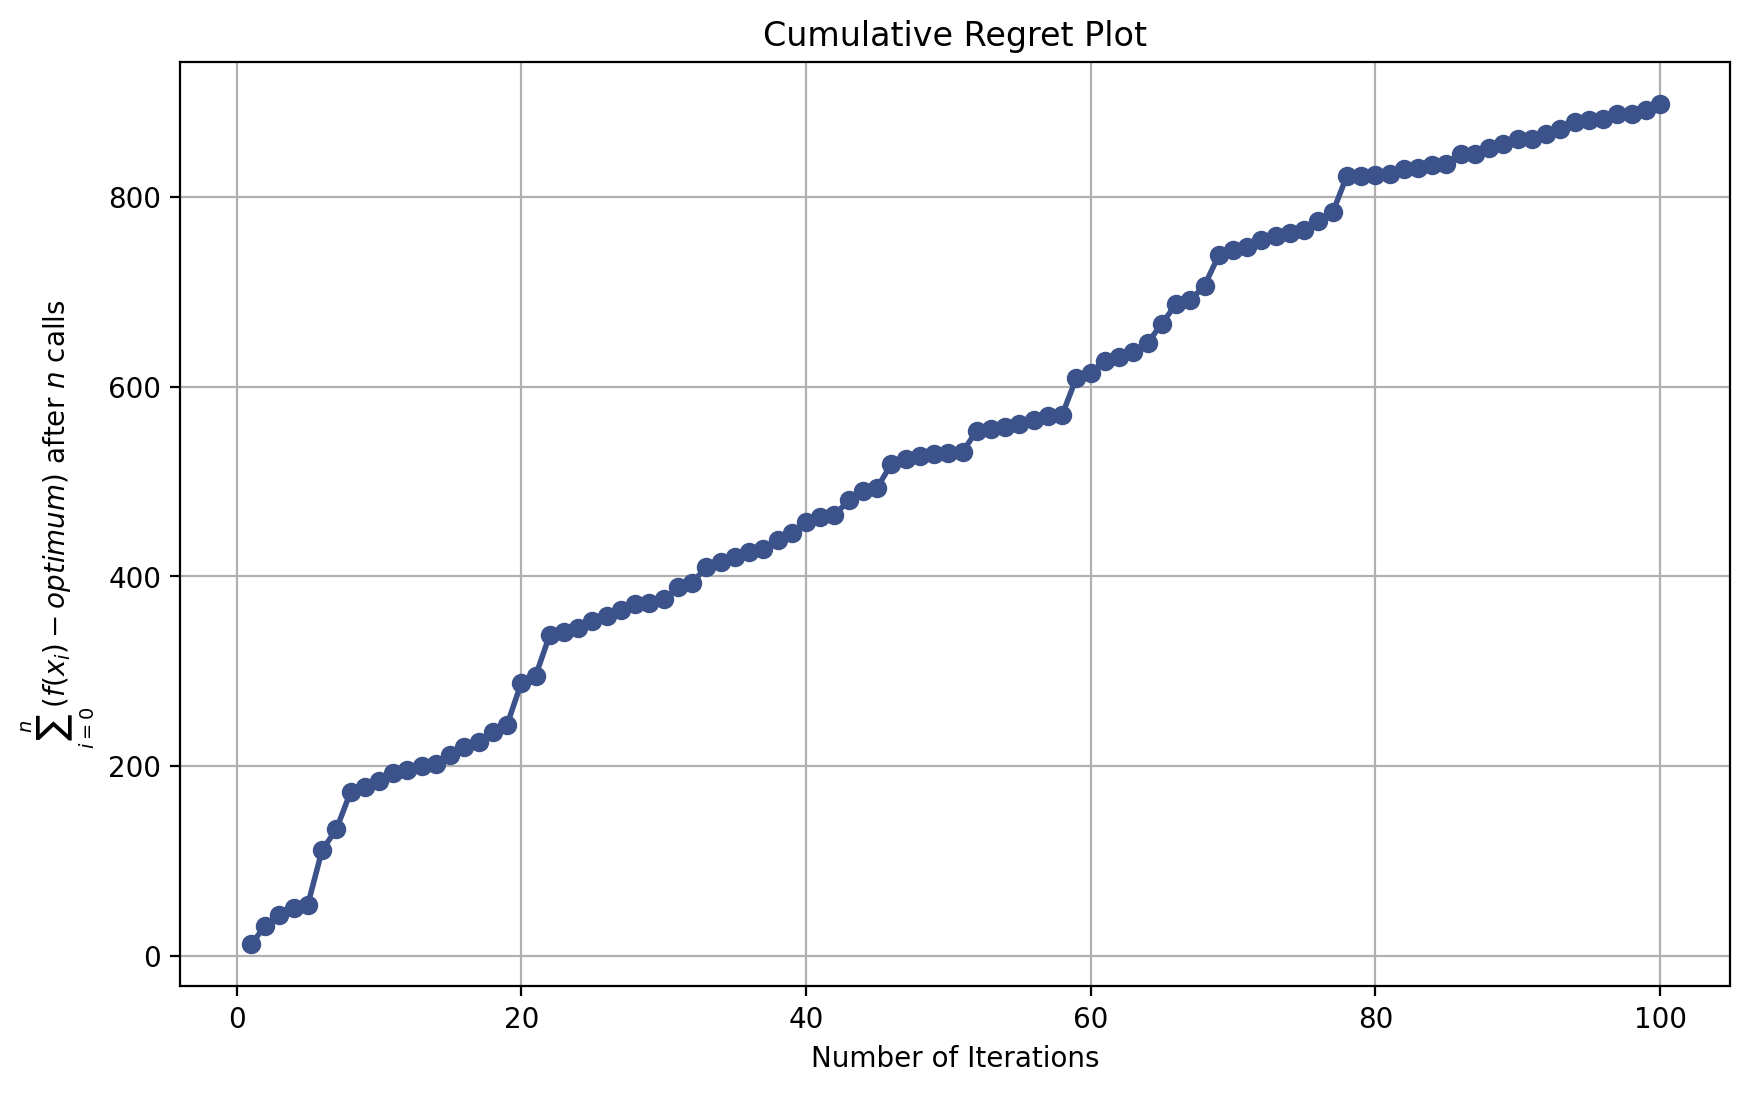

In [21]:
# Load the result object to a file using pickle
with open(pickle_filename, 'rb') as f:
    result = pickle.load(f)

# Plot Convergence: Shows the objective function value over iterations
def plot_convergence_gp(result, filename):
    plt.figure(figsize=(10, 6))
    plot_convergence(result)
    plt.title("Convergence Plot")
    plt.xlabel("Number of Iterations")
    plt.ylabel("Objective Function Value")
    plt.grid(True)
    plt.savefig(filename)
    plt.show()

# Plot Objective: Shows the pairwise partial dependence of the objective function
# on each pair of dimensions
def plot_objective_gp(result, filename):
    plt.figure(figsize=(10, 8))
    plot_objective(result)
    plt.suptitle("Partial Dependence Plot (Gaussian Process)")
    plt.savefig(filename)
    plt.show()

# Plot Evaluations: Visualizes the order in which the parameter space was sampled
def plot_evaluations_gp(result, filename):
    plt.figure(figsize=(10, 8))
    plot_evaluations(result)
    plt.suptitle("Parameter Space Evaluations")
    plt.savefig(filename)
    plt.show()

# Plot Evaluations: Visualizes the order in which the parameter space was sampled
def plot_regret_gp(result, filename):
    plt.figure(figsize=(10, 6))
    plot_regret(result)
    plt.title("Cumulative Regret Plot")
    plt.xlabel("Number of Iterations")
    plt.savefig(filename)
    plt.show()

# Call the plotting functions to visualize the optimization results
plot_convergence_gp(result, "img/convergence.png")
plot_objective_gp(result, "img/partial_dependece.png")
plot_evaluations_gp(result, "img/parameter_space.png")
plot_regret_gp(result, "img/cumulative_regret.png")

In [22]:
all_weight_results = []
min_indices = []
for weights in weight_combinations:
    # Construct the filename based on the current set of weights
    filename_weights = "_".join(map(lambda x: str(x).replace('.', 'p'), weights))
    output_filename = f'results/output_{filename_weights}.pkl'
    pickle_filename = f'data/gp_minimize_result_{filename_weights}.pkl'

    print(f"--- Processing for weights: {weights} ---")
    
    # Check if the file exists before trying to load it
    if not os.path.exists(output_filename):
        print(f"File not found: {output_filename}. Skipping this combination.")
        continue

    # Load the data from the pickle file
    try:
        with open(pickle_filename, 'rb') as f:
            result = pickle.load(f)
        min_indices.append(np.argmin(result.func_vals))
        print(min_indices[-1], result.func_vals[min_indices[-1]])
        
        with open(output_filename, 'rb') as f:
            loaded_output_list = pickle.load(f)

        # Extract the last element of each list for the desired statistics
        norm_emit_x = [stats['norm_emit_x'][-1] for stats in loaded_output_list]
        norm_emit_y = [stats['norm_emit_y'][-1] for stats in loaded_output_list]
        sigma_energy = [stats['sigma_energy'][-1] for stats in loaded_output_list]

        sigma_x = [stats['sigma_x'][-1] for stats in loaded_output_list]
        sigma_xp = [stats['sigma_xp'][-1] for stats in loaded_output_list]
        sigma_y = [stats['sigma_y'][-1] for stats in loaded_output_list]
        sigma_yp = [stats['sigma_yp'][-1] for stats in loaded_output_list]
        sigma_z = [stats['sigma_z'][-1] for stats in loaded_output_list]
        mean_kinetic_energy = [stats['mean_kinetic_energy'][-1] for stats in loaded_output_list]

        # Store the extracted results in a dictionary and append to the main list
        results = {
            'weights': weights,
            'norm_emit_x': norm_emit_x,
            'norm_emit_y': norm_emit_y,
            'sigma_energy': sigma_energy,
            'sigma_x': sigma_x,
            'sigma_xp': sigma_xp,
            'sigma_y': sigma_y,
            'sigma_yp': sigma_yp,
            'sigma_z': sigma_z,
            'mean_kinetic_energy': mean_kinetic_energy,
        }
        all_weight_results.append(results)
        
        print(f"Successfully loaded and extracted data for {len(loaded_output_list)} runs.")
    
    except Exception as e:
        print(f"An error occurred while processing {output_filename}: {e}")

print("\n--- All Data Processed ---")
print(f"Total number of weight combinations processed: {len(all_weight_results)}")

--- Processing for weights: [0.05, 0.05, 0.9] ---
86 0.43068979985834743
Successfully loaded and extracted data for 100 runs.
--- Processing for weights: [0.1, 0.1, 0.8] ---
85 0.3933466515533746
Successfully loaded and extracted data for 100 runs.
--- Processing for weights: [0.15, 0.15, 0.7] ---
17 0.5173456263136194
Successfully loaded and extracted data for 100 runs.
--- Processing for weights: [0.2, 0.2, 0.6] ---
86 1.0451298232896922
Successfully loaded and extracted data for 100 runs.
--- Processing for weights: [0.25, 0.25, 0.5] ---
38 1.075519666730424
Successfully loaded and extracted data for 100 runs.
--- Processing for weights: [0.3, 0.3, 0.4] ---
98 1.44535731359855
Successfully loaded and extracted data for 100 runs.
--- Processing for weights: [0.35, 0.35, 0.3] ---
95 1.0754159545852255
Successfully loaded and extracted data for 100 runs.
--- Processing for weights: [0.4, 0.4, 0.2] ---
98 1.2064588725331442
Successfully loaded and extracted data for 100 runs.
--- Proces

In [23]:
norm_emit_x = [stats['norm_emit_x'] for stats in all_weight_results]
norm_emit_y = [stats['norm_emit_y'] for stats in all_weight_results]
sigma_energy = [stats['sigma_energy'] for stats in all_weight_results]

sigma_x = [stats['sigma_x'] for stats in all_weight_results]
sigma_xp = [stats['sigma_xp'] for stats in all_weight_results]
sigma_y = [stats['sigma_y'] for stats in all_weight_results]
sigma_yp = [stats['sigma_yp'] for stats in all_weight_results]
sigma_z = [stats['sigma_z'] for stats in all_weight_results]
mean_kinetic_energy = [stats['mean_kinetic_energy'] for stats in all_weight_results]

In [24]:
def plot_objective_space_best(filename):
    param = ['norm_emit_x', 'norm_emit_y', 'sigma_energy']

    # Create subplots for each parameter
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs = axs.flatten()

    for i in range(0, len(weight_combinations)):
        #axs[0].scatter(norm_emit_x[i], norm_emit_y[i], c='b', marker='o')
        axs[0].scatter(norm_emit_x[i][min_indices[i]]*1e6, norm_emit_y[i][min_indices[i]]*1e6, marker='o', label=weight_combinations[i])
        axs[0].set_xlabel(r'$\epsilon_{n, x}$ [mm-mrad]')
        axs[0].set_ylabel(r'$\epsilon_{n, y}$ [mm-mrad]')
        axs[0].set_title(r'$\epsilon_{n, x}$ vs. $\epsilon_{n, y}$')
        axs[0].grid(True)
        axs[0].legend(loc='best')

        #axs[1].scatter(sigma_energy[i], norm_emit_x[i], c='b', marker='o', s=2)
        axs[1].scatter(sigma_energy[i][min_indices[i]]/200e6, norm_emit_x[i][min_indices[i]]*1e6, marker='o', label=weight_combinations[i])
        axs[1].set_xlabel(r'$\Delta E/E$')
        axs[1].set_ylabel(r'$\epsilon_{n, x}$ [mm-mrad]')
        axs[1].set_title(r'$\Delta E/E$ vs. $\epsilon_{n, x}$')
        axs[1].grid(True)
        axs[1].legend(loc='best')

        #axs[2].scatter(sigma_energy[i], norm_emit_y[i], c='b', marker='o', s=2)
        axs[2].scatter(sigma_energy[i][min_indices[i]]/200e6, norm_emit_y[i][min_indices[i]]*1e6, marker='o', label=weight_combinations[i])
        axs[2].set_xlabel(r'$\Delta E/E$')
        axs[2].set_ylabel(r'$\epsilon_{n, y}$ [mm-mrad]')
        axs[2].set_title(r'$\Delta E/E$ vs. $\epsilon_{n, y}$')
        axs[2].grid(True)
        axs[2].legend(loc='best')

    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

In [25]:
def plot_objective_space_all(filename):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs = axs.flatten()

    for i in range(0, len(weight_combinations)):
        axs[0].scatter([x*1e6 for x in norm_emit_x[i]], [x*1e6 for x in norm_emit_y[i]], c='b', marker='o', s=2)
        axs[0].scatter(norm_emit_x[i][min_indices[i]]*1e6, norm_emit_y[i][min_indices[i]]*1e6, c='r', marker='o', label=weight_combinations[i])
        axs[0].set_xlabel(r'$\epsilon_{n, x}$ [mm-mrad]')
        axs[0].set_ylabel(r'$\epsilon_{n, y}$ [mm-mrad]')
        axs[0].set_title(r'$\epsilon_{n, x}$ vs. $\epsilon_{n, y}$')
        axs[0].grid(True)
        #axs[0].legend(loc='best')

        axs[1].scatter([x / 200e6 for x in sigma_energy[i]], [x*1e6 for x in norm_emit_x[i]], c='b', marker='o', s=2)
        axs[1].scatter(sigma_energy[i][min_indices[i]]/200e6, norm_emit_x[i][min_indices[i]]*1e6, c='r', marker='o', label=weight_combinations[i])
        axs[1].set_xlabel(r'$\Delta E/E$')
        axs[1].set_ylabel(r'$\epsilon_{n, x}$ [mm-mrad]')
        axs[1].set_title(r'$\Delta E/E$ vs. $\epsilon_{n, x}$')
        axs[1].grid(True)
        #axs[1].legend(loc='best')

        axs[2].scatter([x / 200e6 for x in sigma_energy[i]], [x*1e6 for x in norm_emit_y[i]], c='b', marker='o', s=2)
        axs[2].scatter(sigma_energy[i][min_indices[i]]/200e6, norm_emit_y[i][min_indices[i]]*1e6, c='r', marker='o', label=weight_combinations[i])
        axs[2].set_xlabel(r'$\Delta E/E$')
        axs[2].set_ylabel(r'$\epsilon_{n, y}$ [mm-mrad]')
        axs[2].set_title(r'$\Delta E/E$ vs. $\epsilon_{n, y}$')
        axs[2].grid(True)
        #axs[2].legend(loc='best')

    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

In [26]:
def plot_objective_space_all_iter(filename):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs = axs.flatten()
    colors = np.linspace(0, 1, 100)

    for i in range(0, len(weight_combinations)):
        axs[0].scatter([x*1e6 for x in norm_emit_x[i]], [x*1e6 for x in norm_emit_y[i]], marker='o', s=2, c=colors, cmap='cividis')
        axs[0].scatter(norm_emit_x[i][min_indices[i]]*1e6, norm_emit_y[i][min_indices[i]]*1e6, c='r', marker='o', label=weight_combinations[i])
        axs[0].set_xlabel(r'$\epsilon_{n, x}$ [mm-mrad]')
        axs[0].set_ylabel(r'$\epsilon_{n, y}$ [mm-mrad]')
        axs[0].set_title(r'$\epsilon_{n, x}$ vs. $\epsilon_{n, y}$')
        axs[0].grid(True)
        #axs[0].legend(loc='best')

        axs[1].scatter([x / 200e6 for x in sigma_energy[i]], [x*1e6 for x in norm_emit_x[i]], marker='o', s=2, c=colors, cmap='viridis')
        axs[1].scatter(sigma_energy[i][min_indices[i]]/200e6, norm_emit_x[i][min_indices[i]]*1e6, c='r', marker='o', label=weight_combinations[i])
        axs[1].set_xlabel(r'$\Delta E/E$')
        axs[1].set_ylabel(r'$\epsilon_{n, x}$ [mm-mrad]')
        axs[1].set_title(r'$\Delta E/E$ vs. $\epsilon_{n, x}$')
        axs[1].grid(True)
        #axs[1].legend(loc='best')

        axs[2].scatter([x / 200e6 for x in sigma_energy[i]], [x*1e6 for x in norm_emit_y[i]], marker='o', s=2, c=colors, cmap='viridis')
        axs[2].scatter(sigma_energy[i][min_indices[i]]/200e6, norm_emit_y[i][min_indices[i]]*1e6, c='r', marker='o', label=weight_combinations[i])
        axs[2].set_xlabel(r'$\Delta E/E$')
        axs[2].set_ylabel(r'$\epsilon_{n, y}$ [mm-mrad]')
        axs[2].set_title(r'$\Delta E/E$ vs. $\epsilon_{n, y}$')
        axs[2].grid(True)
        #axs[2].legend(loc='best')

    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

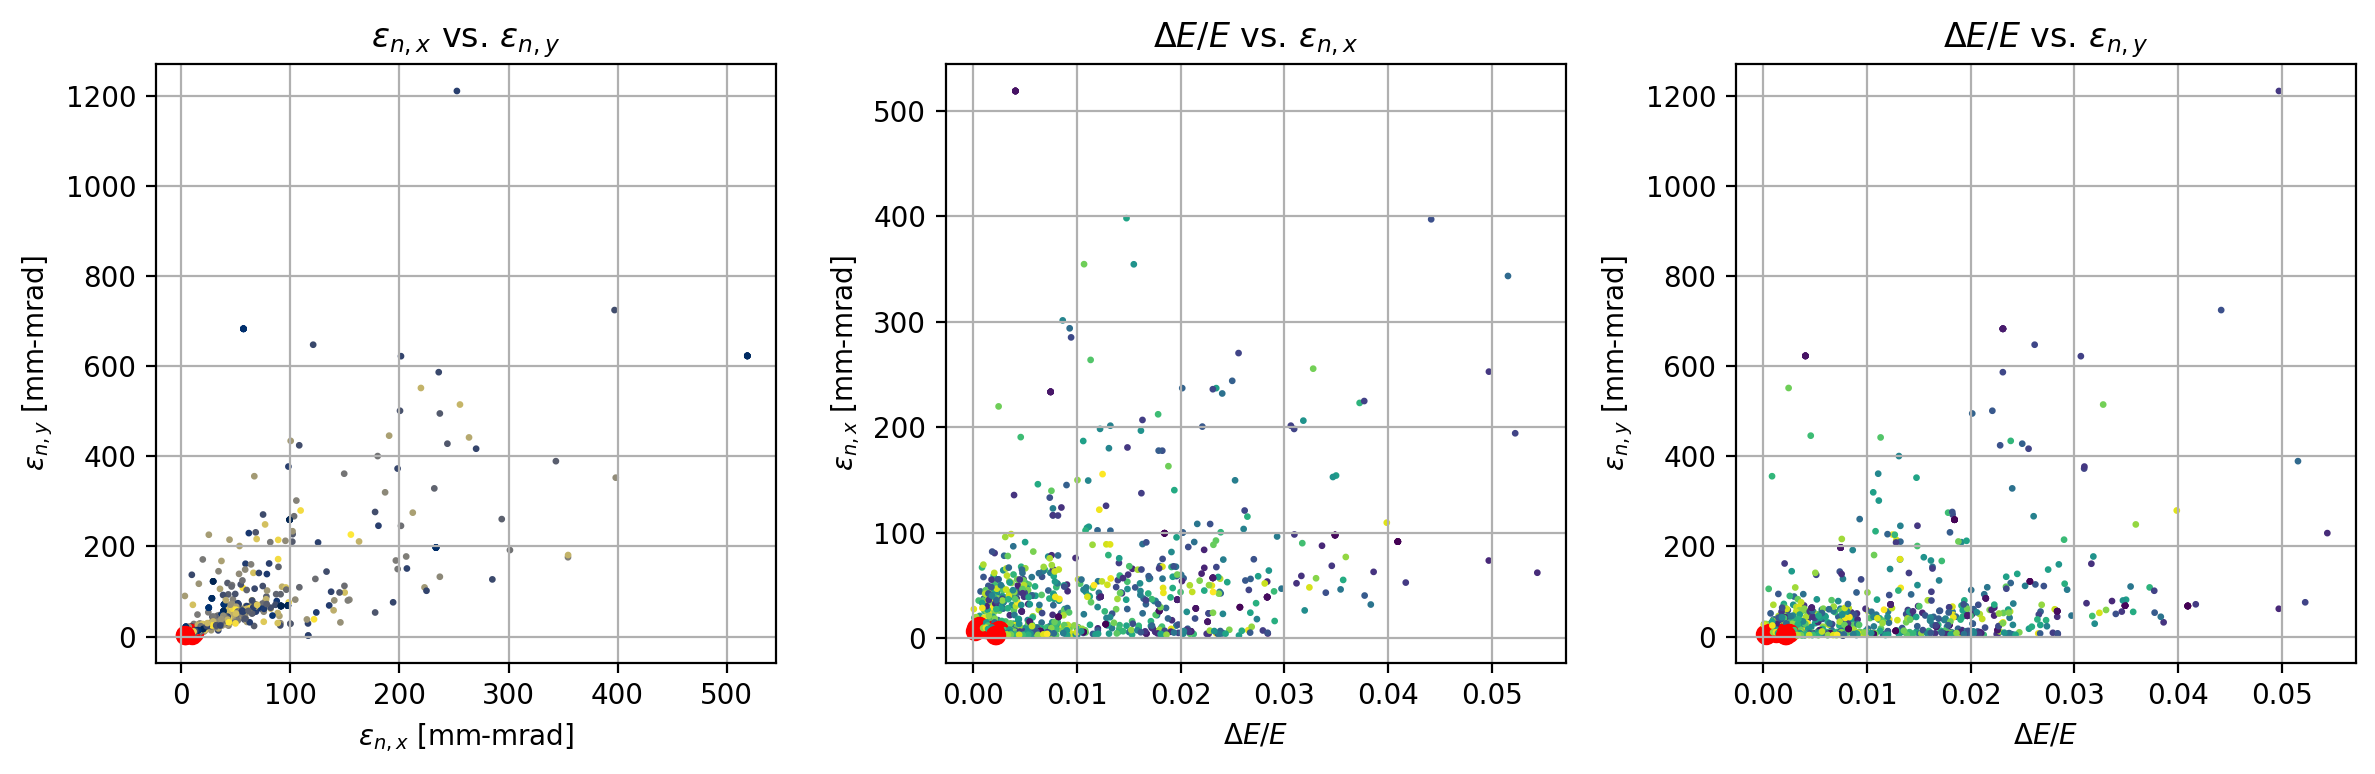

In [27]:
plot_objective_space_all_iter('test.png')

In [28]:
def plot_constraint_space_all(filename):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs = axs.flatten()

    for i in range(0, len(weight_combinations)):

        axs[0].scatter([x*1e3 for x in sigma_x[i]], [x*1e3 for x in sigma_xp[i]], c='b', marker='o', s=2)
        axs[0].scatter(sigma_x[i][min_indices[i]]*1e3, sigma_xp[i][min_indices[i]]*1e3, c='r', marker='o', label=weight_combinations[i])
        axs[0].axvline(0.3, color='purple', linestyle='--')
        axs[0].axhline(0.3, color='purple', linestyle='--')
        axs[0].set_xlabel(r'$\sigma_x$ [mm]')
        axs[0].set_ylabel(r'$\sigma_{x^{\prime}}$ [mrad]')
        axs[0].set_title(r'$\sigma_x$ vs. $\sigma_{x^{\prime}}$')
        axs[0].grid(True)
        #axs[0].legend(loc='best')

        axs[1].scatter([x*1e3 for x in sigma_y[i]], [x*1e3 for x in sigma_yp[i]], c='b', marker='o', s=2)
        axs[1].scatter(sigma_y[i][min_indices[i]]*1e3, sigma_yp[i][min_indices[i]]*1e3, c='r', marker='o', label=weight_combinations[i])
        axs[1].axvline(0.3, color='purple', linestyle='--')
        axs[1].axhline(0.3, color='purple', linestyle='--')
        axs[1].set_xlabel(r'$\sigma_y$ [mm]')
        axs[1].set_ylabel(r'$\sigma_{y^{\prime}}$ [mrad]')
        axs[1].set_title(r'$\sigma_y$ vs. $\sigma_{y^{\prime}}$')
        axs[1].grid(True)
        #axs[1].legend(loc='best')

        axs[2].scatter([x*1e3 for x in sigma_z[i]], [x/200e6 for x in mean_kinetic_energy[i]], c='b', marker='o', s=2) 
        axs[2].scatter(sigma_z[i][min_indices[i]]*1e3, mean_kinetic_energy[i][min_indices[i]]/200e6, c='r', marker='o', label=weight_combinations[i])
        axs[2].axvline(1.0, color='purple', linestyle='--')
        axs[2].axhline(205/200, color='purple', linestyle='--')
        axs[2].axhline(195/200, color='purple', linestyle='--')
        axs[2].set_xlabel(r'$\sigma_z$ [mm]')
        axs[2].set_ylabel(r'$<E>$ [MeV]')
        axs[2].set_title(r'$\sigma_z$ vs. $<E>$')
        axs[2].grid(True)
        #axs[2].legend(loc='best')
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

In [29]:
for i in range(0, len(weight_combinations)):
    print (weight_combinations[i], norm_emit_x[i][-1], norm_emit_y[i][-1], sigma_energy[i][-1])

[0.05, 0.05, 0.9] 1.0127e-05 1.0275e-05 290220.0
[0.1, 0.1, 0.8] 3.7225e-05 3.7225e-05 423660.0
[0.15, 0.15, 0.7] 0.00015544 0.0002261 2499500.0
[0.2, 0.2, 0.6] 4.9987999999999996e-05 5.9464e-05 2334600.0
[0.25, 0.25, 0.5] 8.8058e-06 8.552099999999999e-06 1242600.0
[0.3, 0.3, 0.4] 7.9004e-06 9.1867e-06 470270.0
[0.35, 0.35, 0.3] 4.358e-05 3.1485e-05 4627100.0
[0.4, 0.4, 0.2] 2.9354e-06 3.1792999999999998e-06 418070.0
[0.45, 0.45, 0.1] 3.7204e-06 3.4742e-06 1431800.0


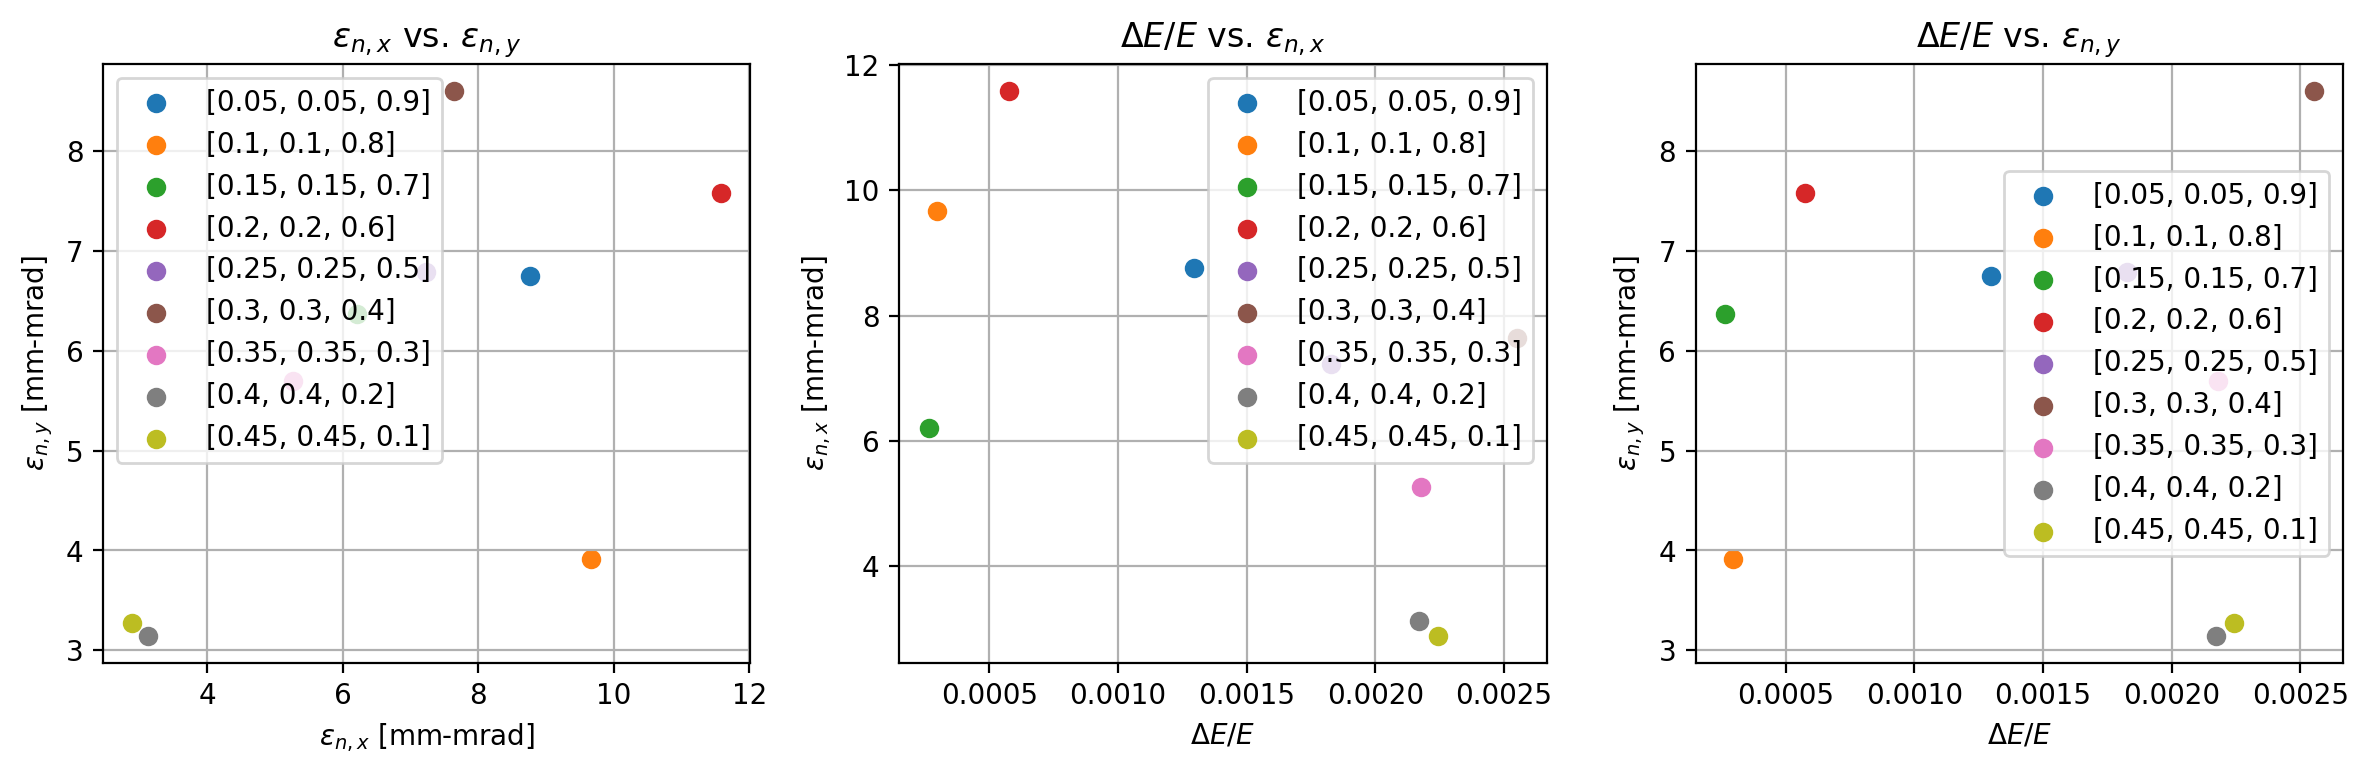

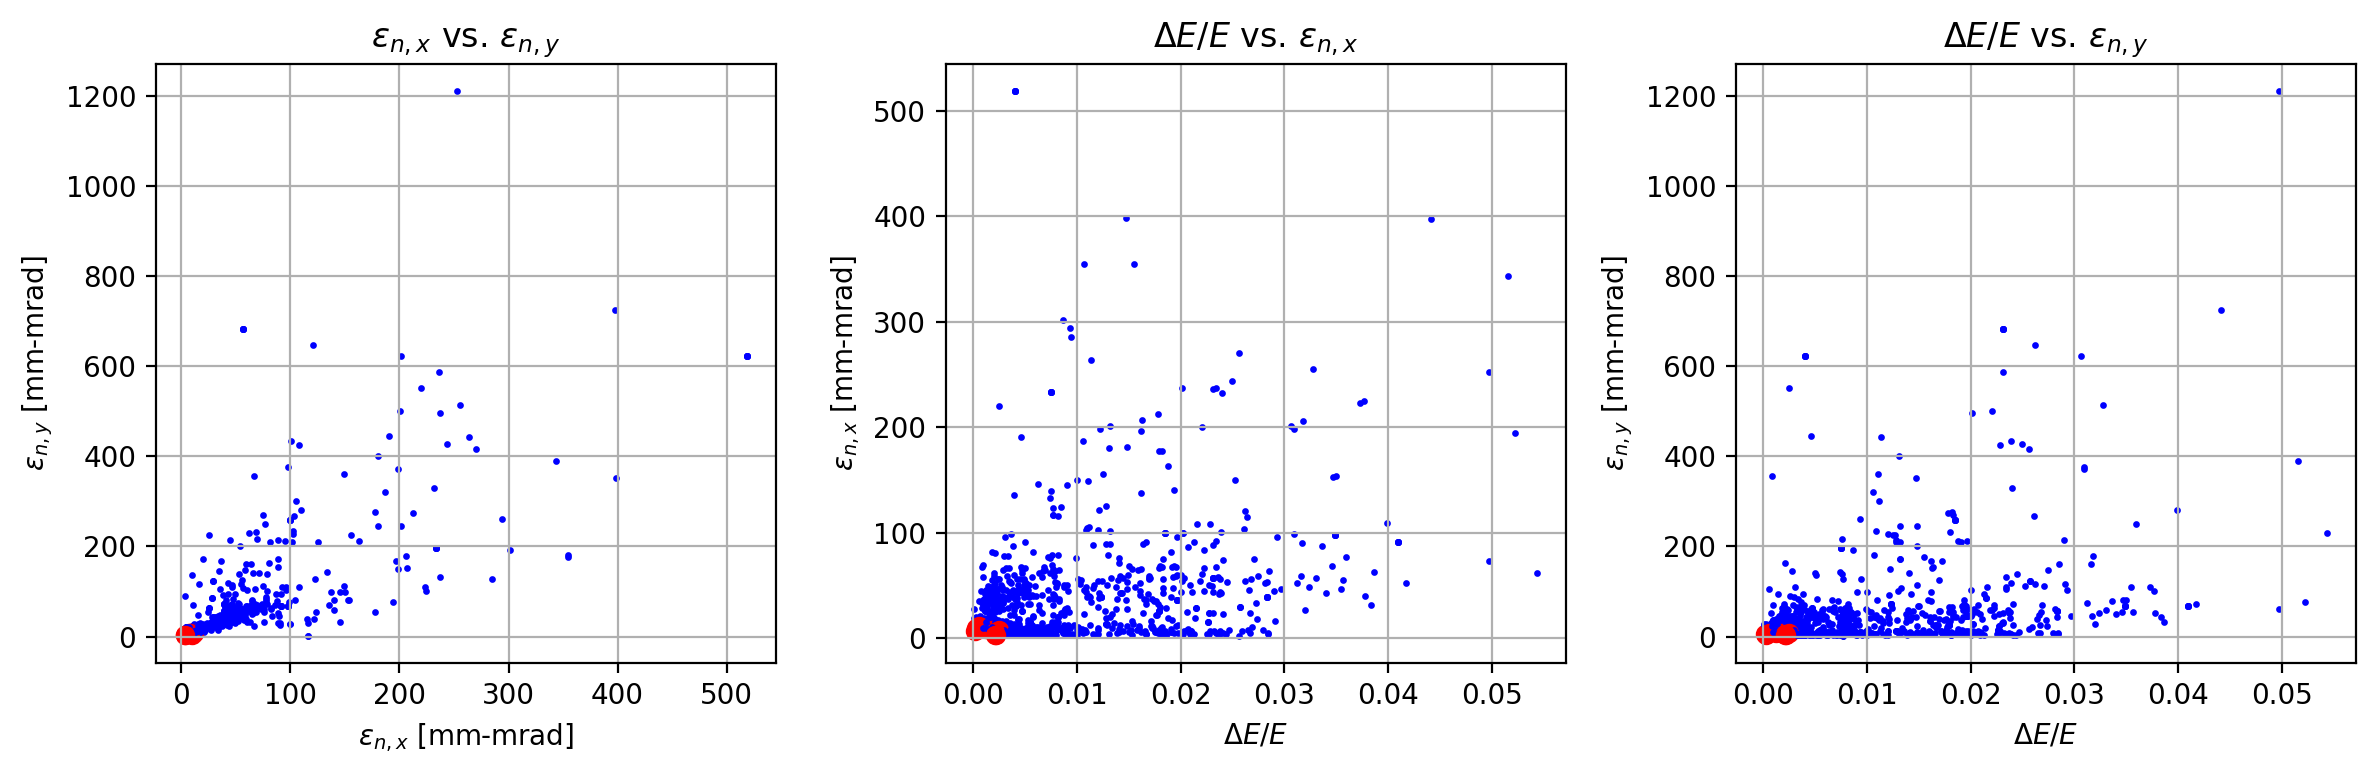

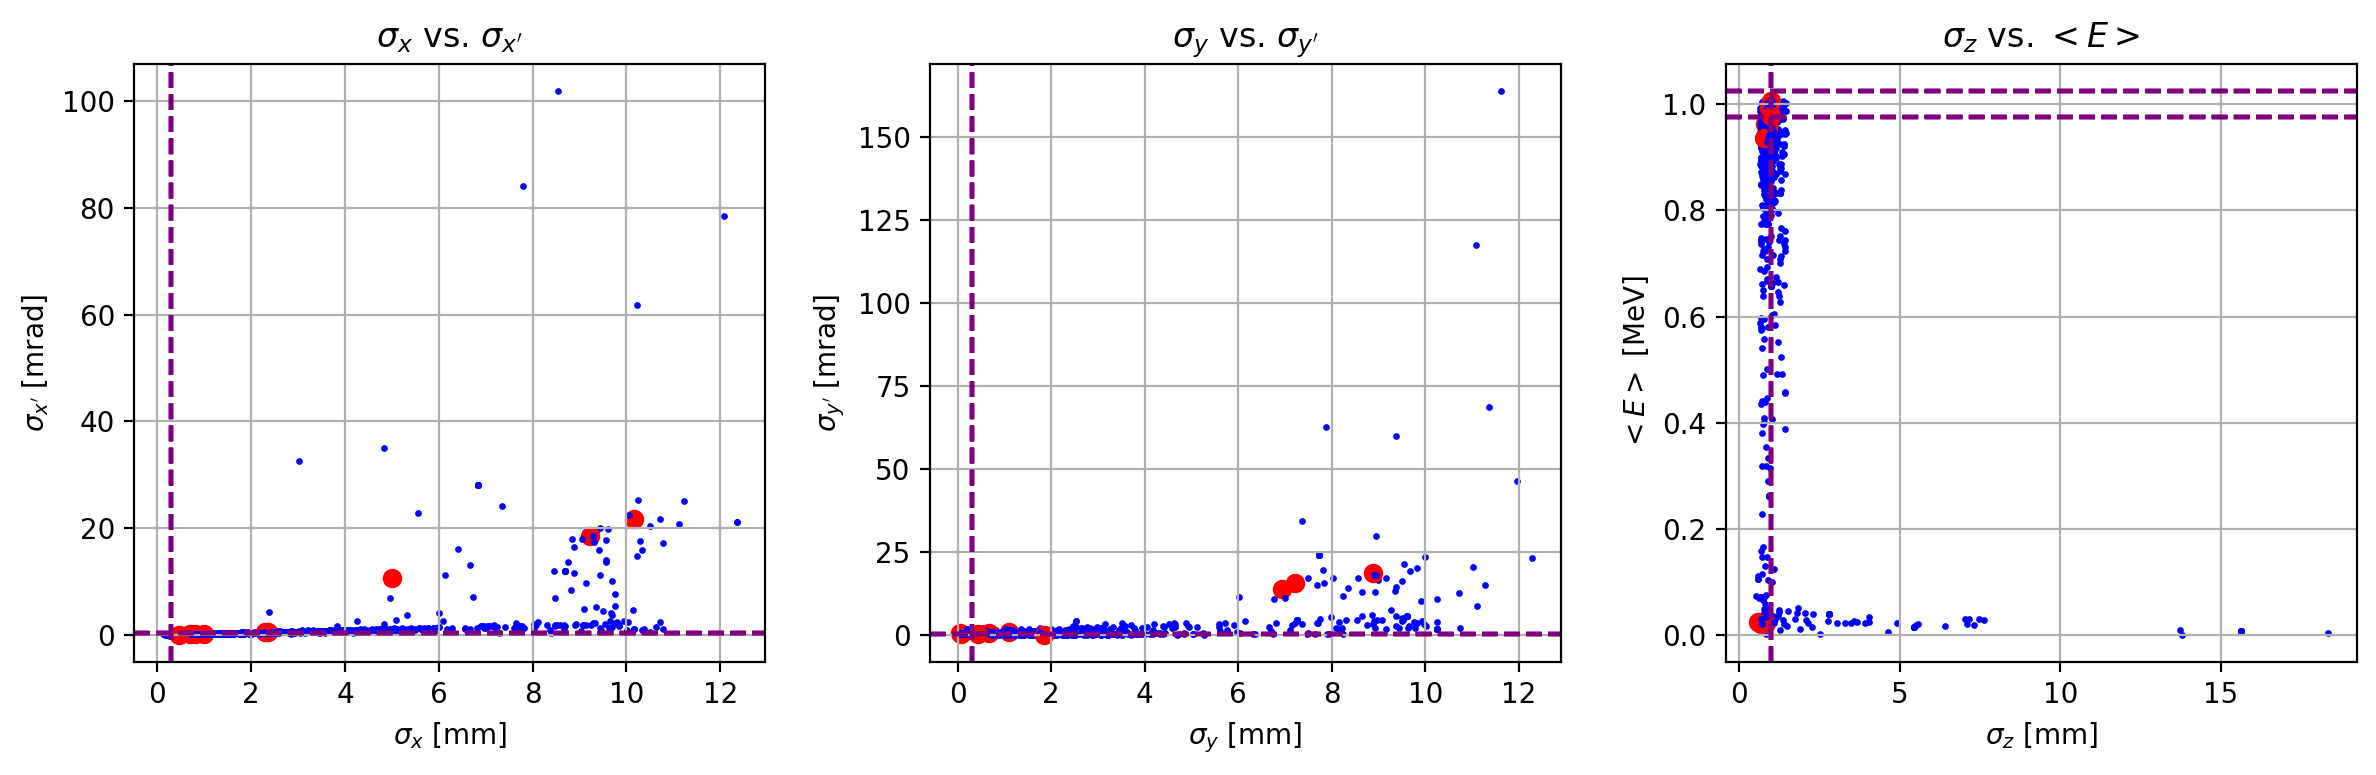

In [30]:
plot_objective_space_best("img/objective_space_best.png")
plot_objective_space_all("img/objective_space_all.png")
plot_constraint_space_all("img/constraint_space_all.png")

In [31]:
def plot_convergence_all(*args, cc, label):
    for results, color in zip(args, colors):

        if isinstance(results, OptimizeResult):
            n_calls = len(results.x_iters)
            mins = [np.min(results.func_vals[:i])
                    for i in range(1, n_calls + 1)]
            ax.plot(range(1, n_calls + 1), mins, c=cc,
                    marker=".", markersize=12, lw=2, label=label)

        elif isinstance(results, list):
            n_calls = len(results[0].x_iters)
            iterations = range(1, n_calls + 1)
            mins = [[np.min(r.func_vals[:i]) for i in iterations]
                    for r in results]

            for m in mins:
                ax.plot(iterations, m, c=color, alpha=0.2)

            ax.plot(iterations, np.mean(mins, axis=0), c=color,
                    marker=".", markersize=12, lw=2, label=name)
            ax.grid()

/tmp/ipykernel_215918/2418145235.py:8: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax.plot(range(1, n_calls + 1), mins, c=cc,


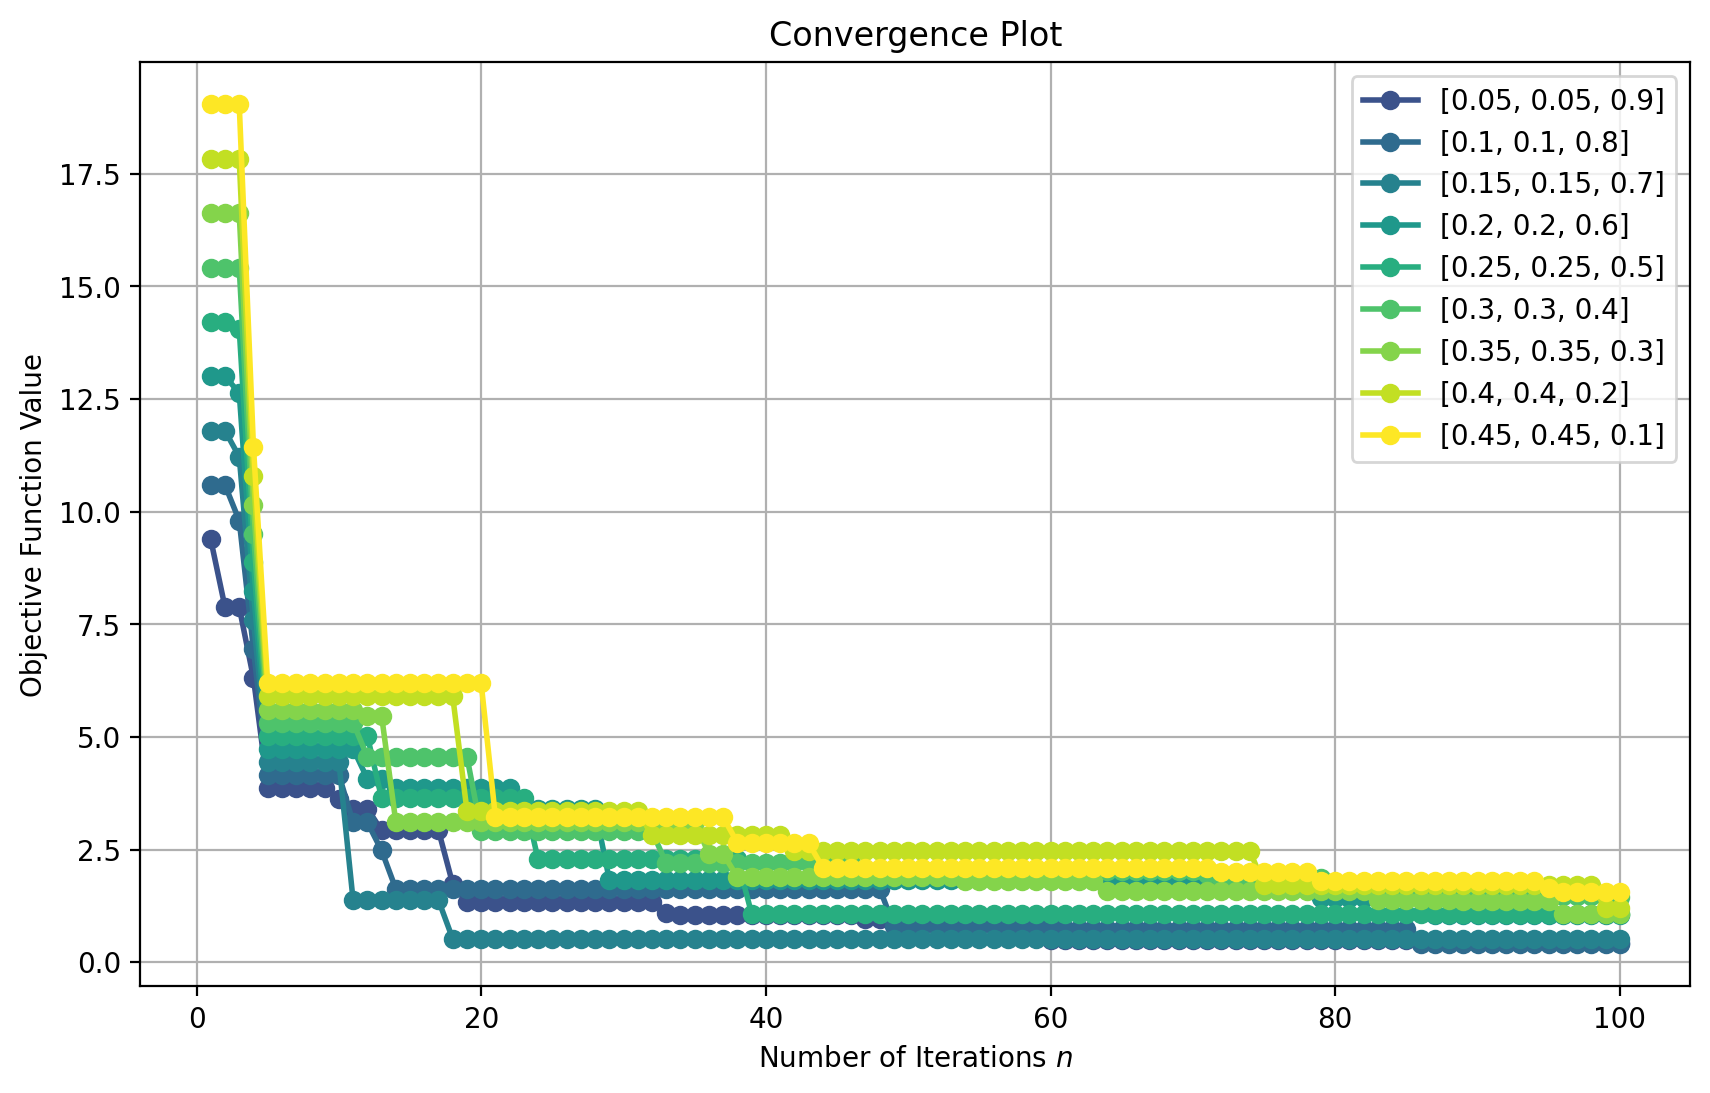

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = cm.viridis(np.linspace(0.25, 1.0, len(weight_combinations)))

index = 0

for weights in weight_combinations:
    filename_weights = "_".join(map(lambda x: str(x).replace('.', 'p'), weights))
    pickle_filename = f'data/gp_minimize_result_{filename_weights}.pkl'

    with open(pickle_filename, 'rb') as f:
        result = pickle.load(f)

    plot_convergence_all(result, cc=colors[index], label=weights)

    index += 1

ax.set_title("Convergence Plot")
ax.set_xlabel("Number of Iterations $n$")
ax.set_ylabel("Objective Function Value")
ax.legend()
ax.grid()
fig.savefig("img/convergence_all.png")

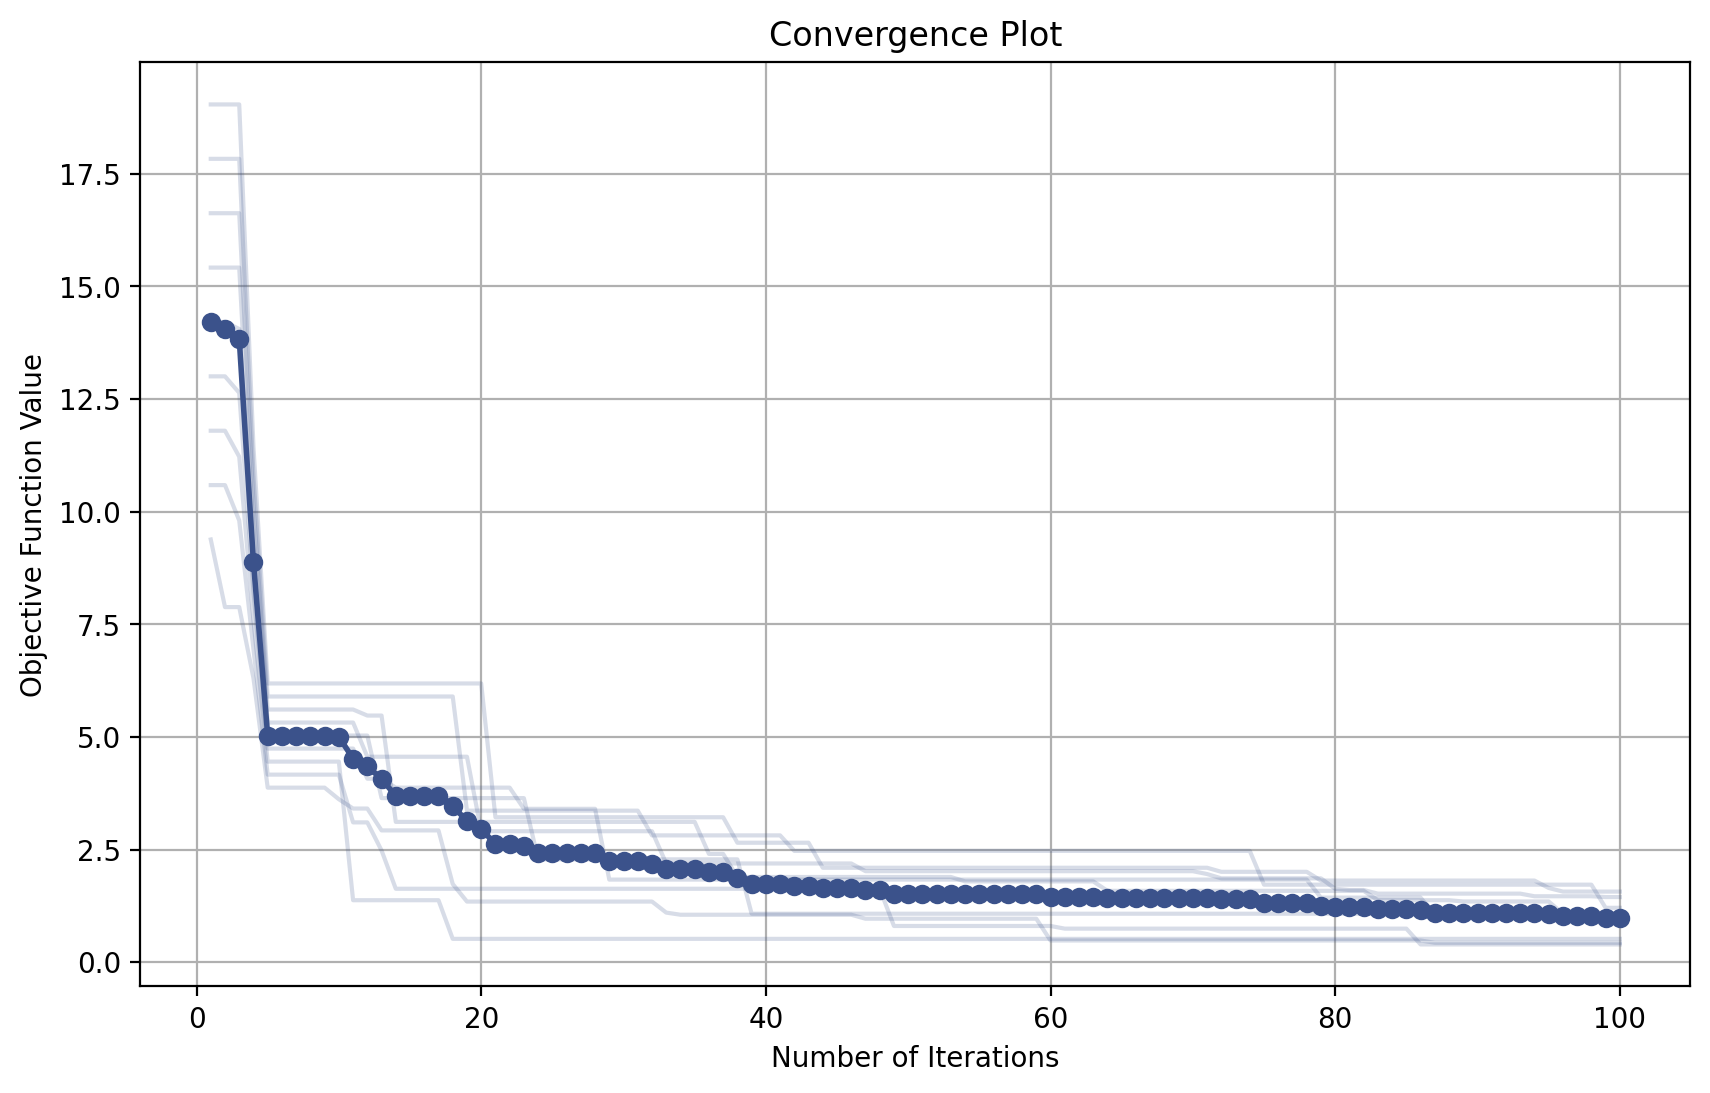

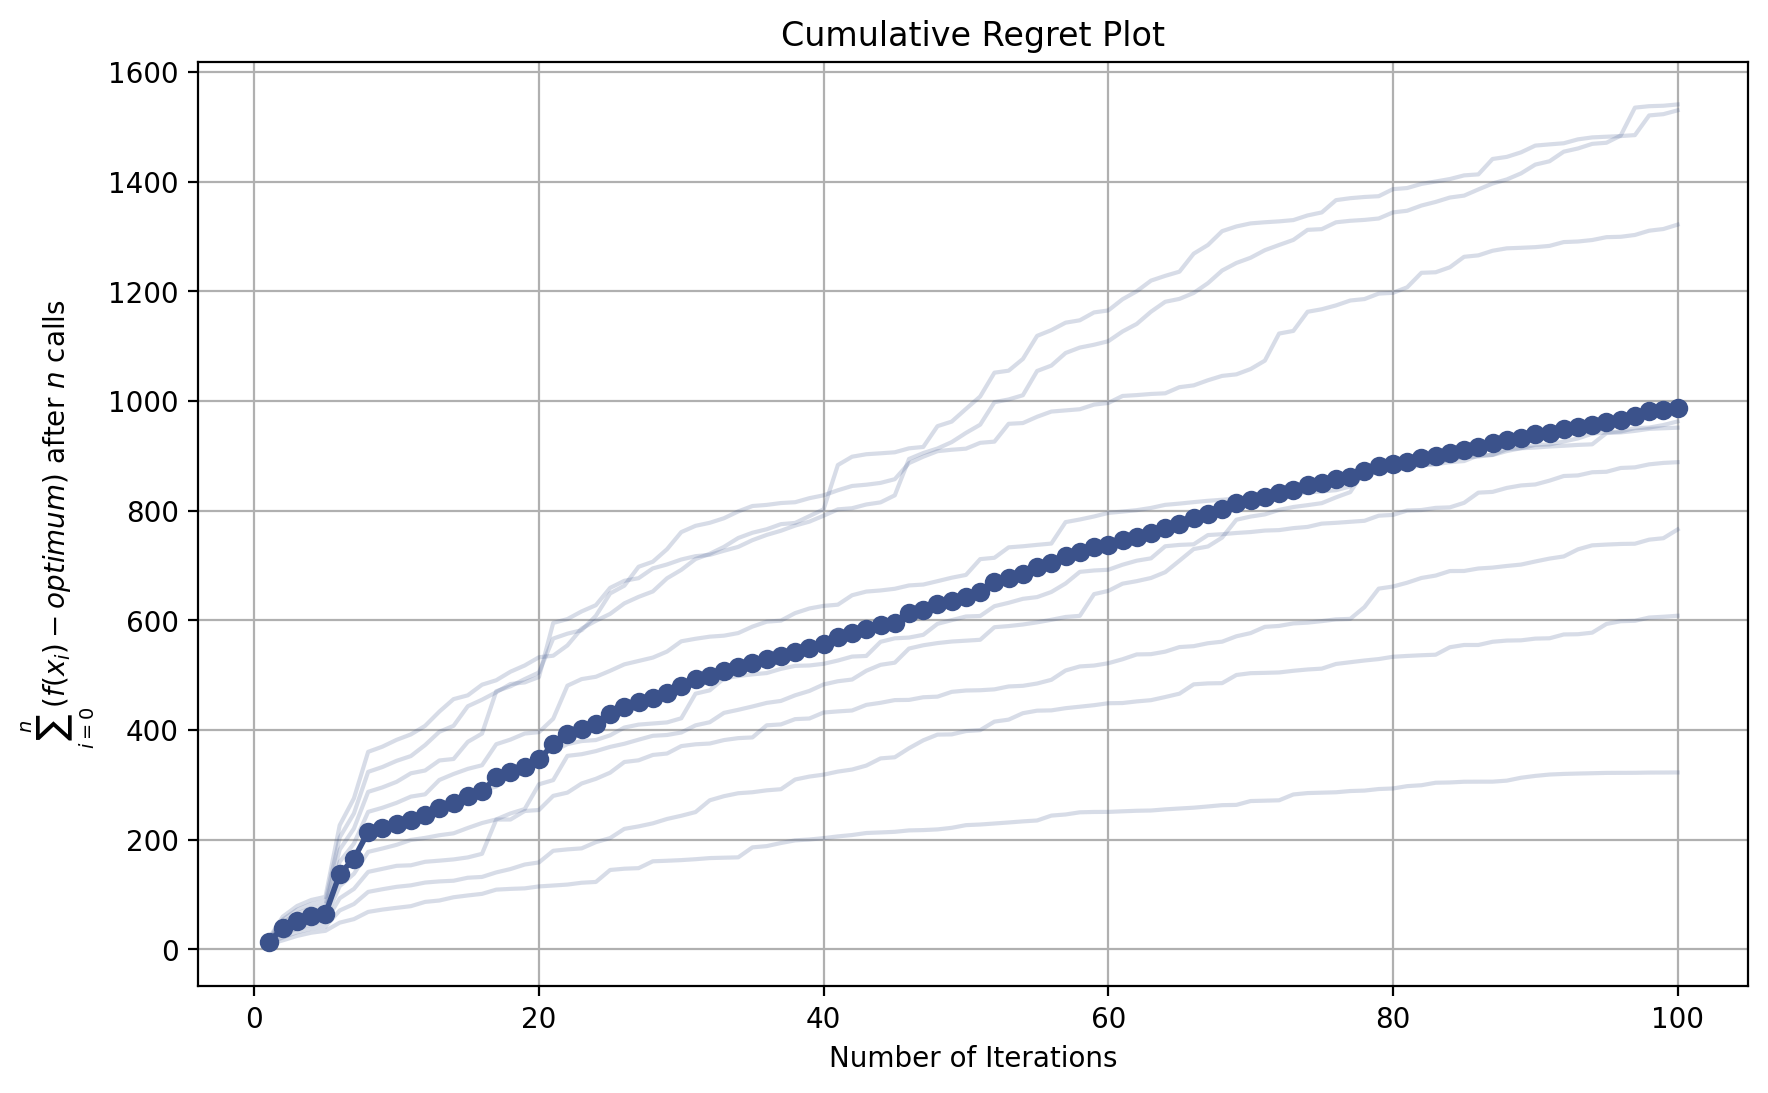

In [33]:
results = []

for weights in weight_combinations:
    filename_weights = "_".join(map(lambda x: str(x).replace('.', 'p'), weights))
    pickle_filename = f'data/gp_minimize_result_{filename_weights}.pkl'

    with open(pickle_filename, 'rb') as f:
        result = pickle.load(f)
    results.append(result)

filename = "img/convergence_gp.png"
plot_convergence_gp(results, filename)
filename = "img/regret_gp.png"
plot_regret_gp(results, filename)

In [34]:
def plot_regret_all(*args, cc, label, true_minimum=None):
    if true_minimum is None:
        new_results = []
        for res in args:
            if isinstance(res, tuple):
                res = res[1]
            if isinstance(res, OptimizeResult):
                new_results.append(res)
            elif isinstance(res, list):
                new_results.extend(res)
            true_minimum = np.min([np.min(r.func_vals) for r in new_results])

    for results, color in zip(args, colors):
        if isinstance(results, OptimizeResult):
            n_calls = len(results.x_iters)
        
            regrets = [
                np.sum(results.func_vals[:i] - true_minimum)
                for i in range(1, n_calls + 1)
            ]
        
            ax.plot(
                range(1, n_calls + 1),
                regrets,
                c=cc,
                marker=".",
                markersize=12,
                lw=2,
                label=label,
            )

/tmp/ipykernel_215918/4033123341.py:22: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax.plot(


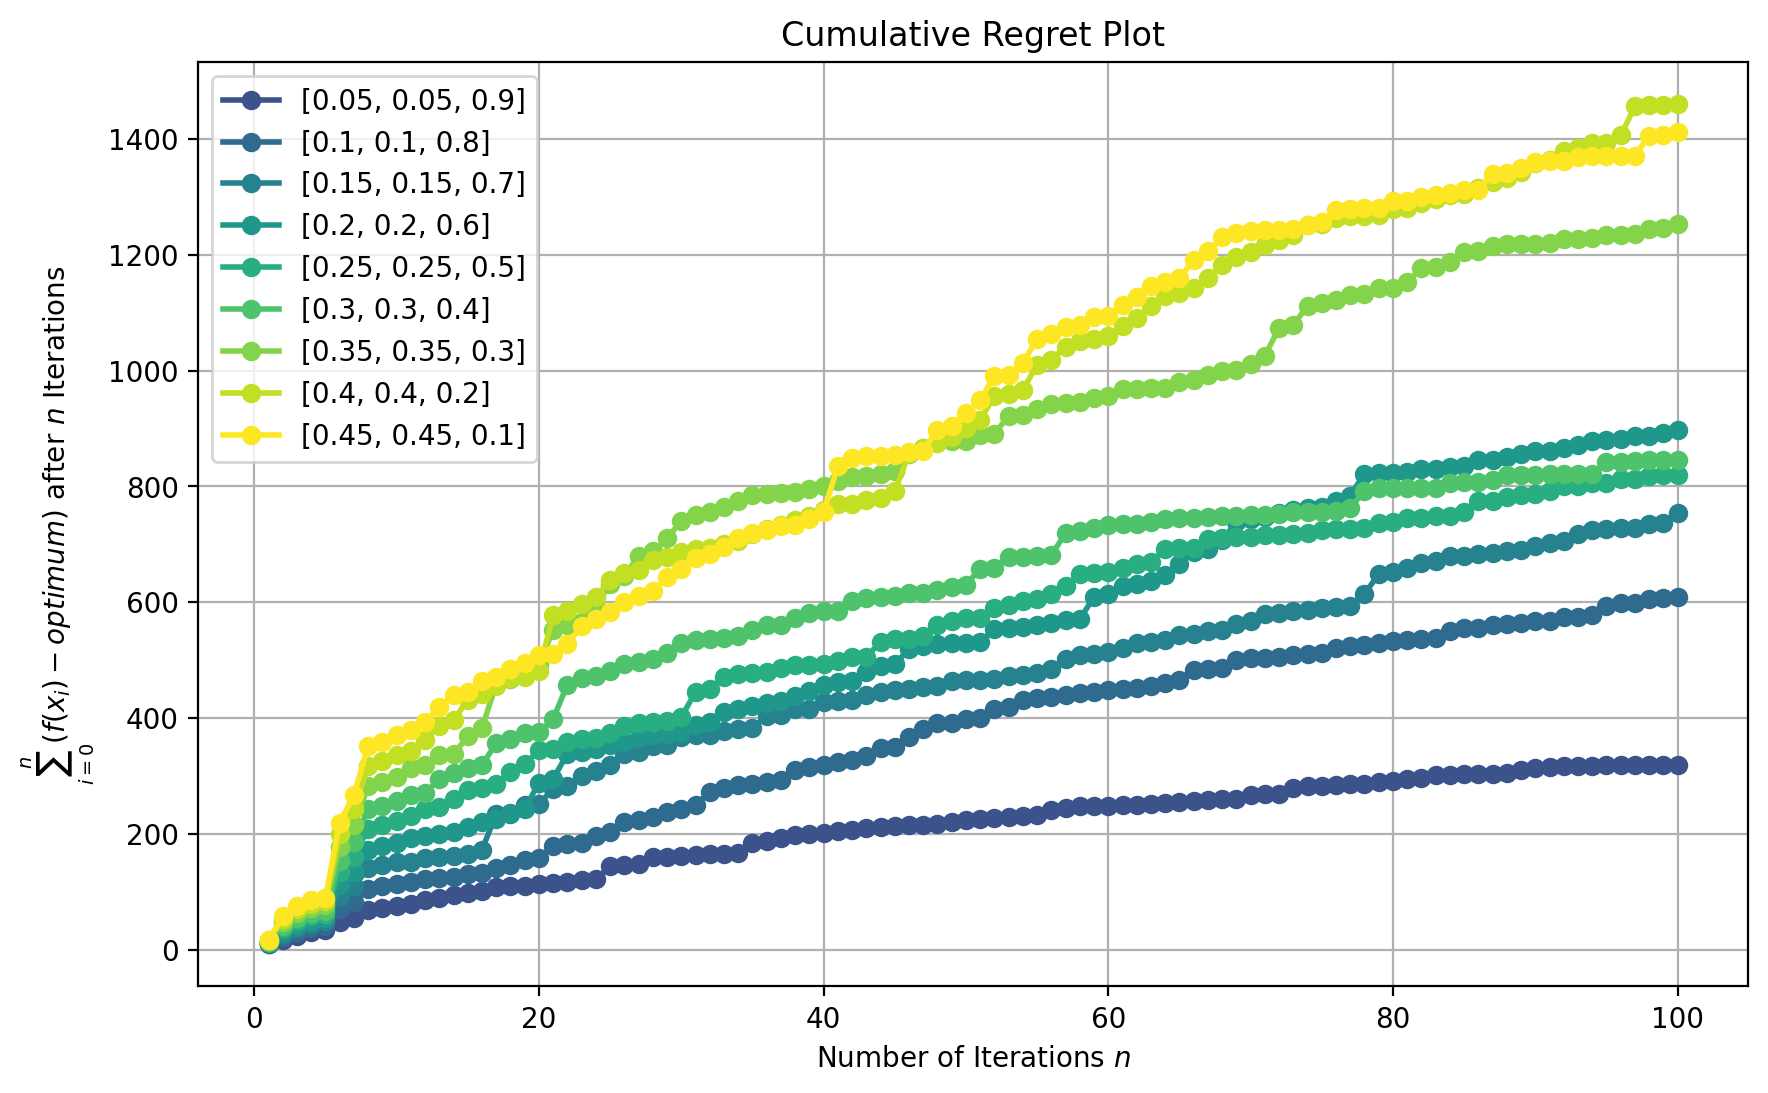

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))

index = 0

for weights in weight_combinations:
    filename_weights = "_".join(map(lambda x: str(x).replace('.', 'p'), weights))
    pickle_filename = f'data/gp_minimize_result_{filename_weights}.pkl'

    with open(pickle_filename, 'rb') as f:
        result = pickle.load(f)

    plot_regret_all(result, cc=colors[index], label=weights)
    
    index += 1
    
ax.set_title("Cumulative Regret Plot")
ax.set_xlabel("Number of Iterations $n$")
ax.set_ylabel(r"$\sum_{i=0}^n(f(x_i) - optimum)$ after $n$ Iterations")
ax.legend()
ax.grid()
fig.savefig("img/cumulative_regret_all.png")

In [36]:
def astra_plot(astra_sim, filename, beamsize=False):
    plt.figure(figsize=(15,8))
    if beamsize:
        astra_sim.plot()
        plt.savefig(filename)
    else:
        astra_sim.plot(['norm_emit_x', 'norm_emit_y'], y2='sigma_energy')
        plt.savefig(filename)
    plt.show()

Weights: [0.15, 0.15, 0.7], min_index: 86
parameters: [0.09738695, 1.109309380379017, -4.330027545, 17.81248842, -48.87436652758681, 465.0801288]
{'mean_z': array([6.4367e-03, 1.2908e-02, 1.9374e-02, ..., 1.6181e+01, 1.6187e+01,
       1.6200e+01]), 'mean_t': array([4.6718e-11, 7.0466e-11, 9.3034e-11, ..., 5.4214e-08, 5.4236e-08,
       5.4279e-08]), 'mean_x': array([ 6.5564e-07,  3.9631e-07,  2.4739e-07, ..., -1.7482e-03,
       -1.7740e-03, -1.8256e-03]), 'sigma_x': array([0.00064575, 0.00074059, 0.00084714, ..., 0.0047891 , 0.0048577 ,
       0.0049949 ]), 'sigma_xp': array([0.017223, 0.014385, 0.019535, ..., 0.010687, 0.010687, 0.010687]), 'norm_emit_x': array([3.4940e-06, 3.1715e-06, 2.6915e-06, ..., 6.2096e-06, 6.2093e-06,
       6.2097e-06]), 'cov_x__xp': array([1.09196325e-05, 1.05941399e-05, 1.65327842e-05, ...,
       5.11763226e-05, 5.19093822e-05, 5.33804963e-05]), 'mean_y': array([-1.0812e-06, -1.2938e-06, -1.4795e-06, ...,  2.5758e-03,
        2.6137e-03,  2.6896e-03]), '

<Figure size 1500x800 with 0 Axes>

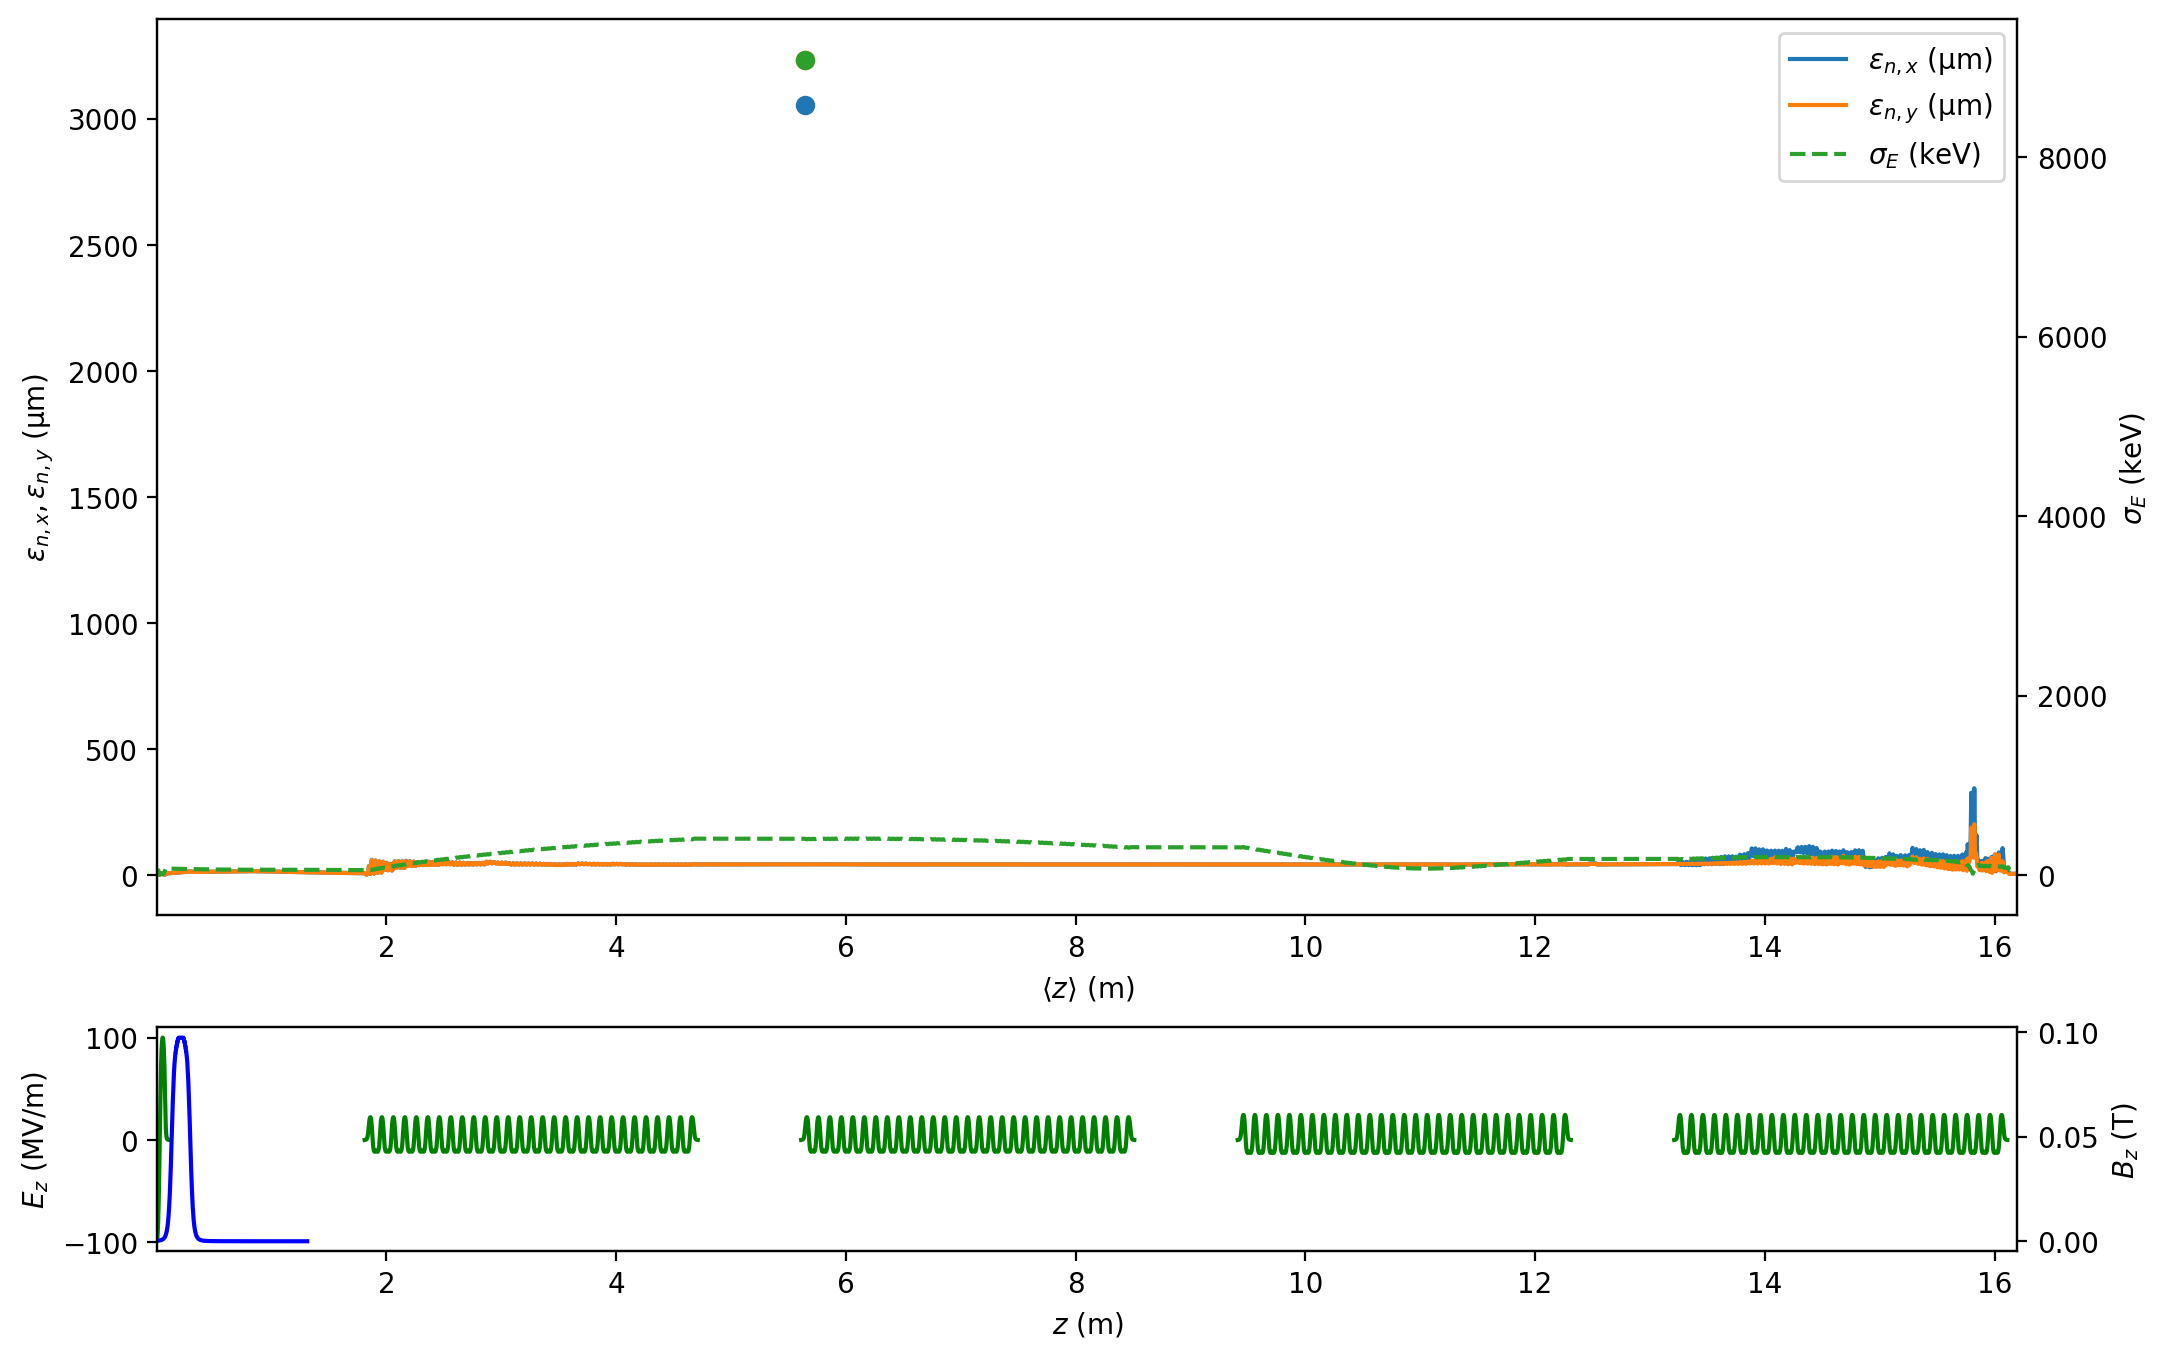

<Figure size 1500x800 with 0 Axes>

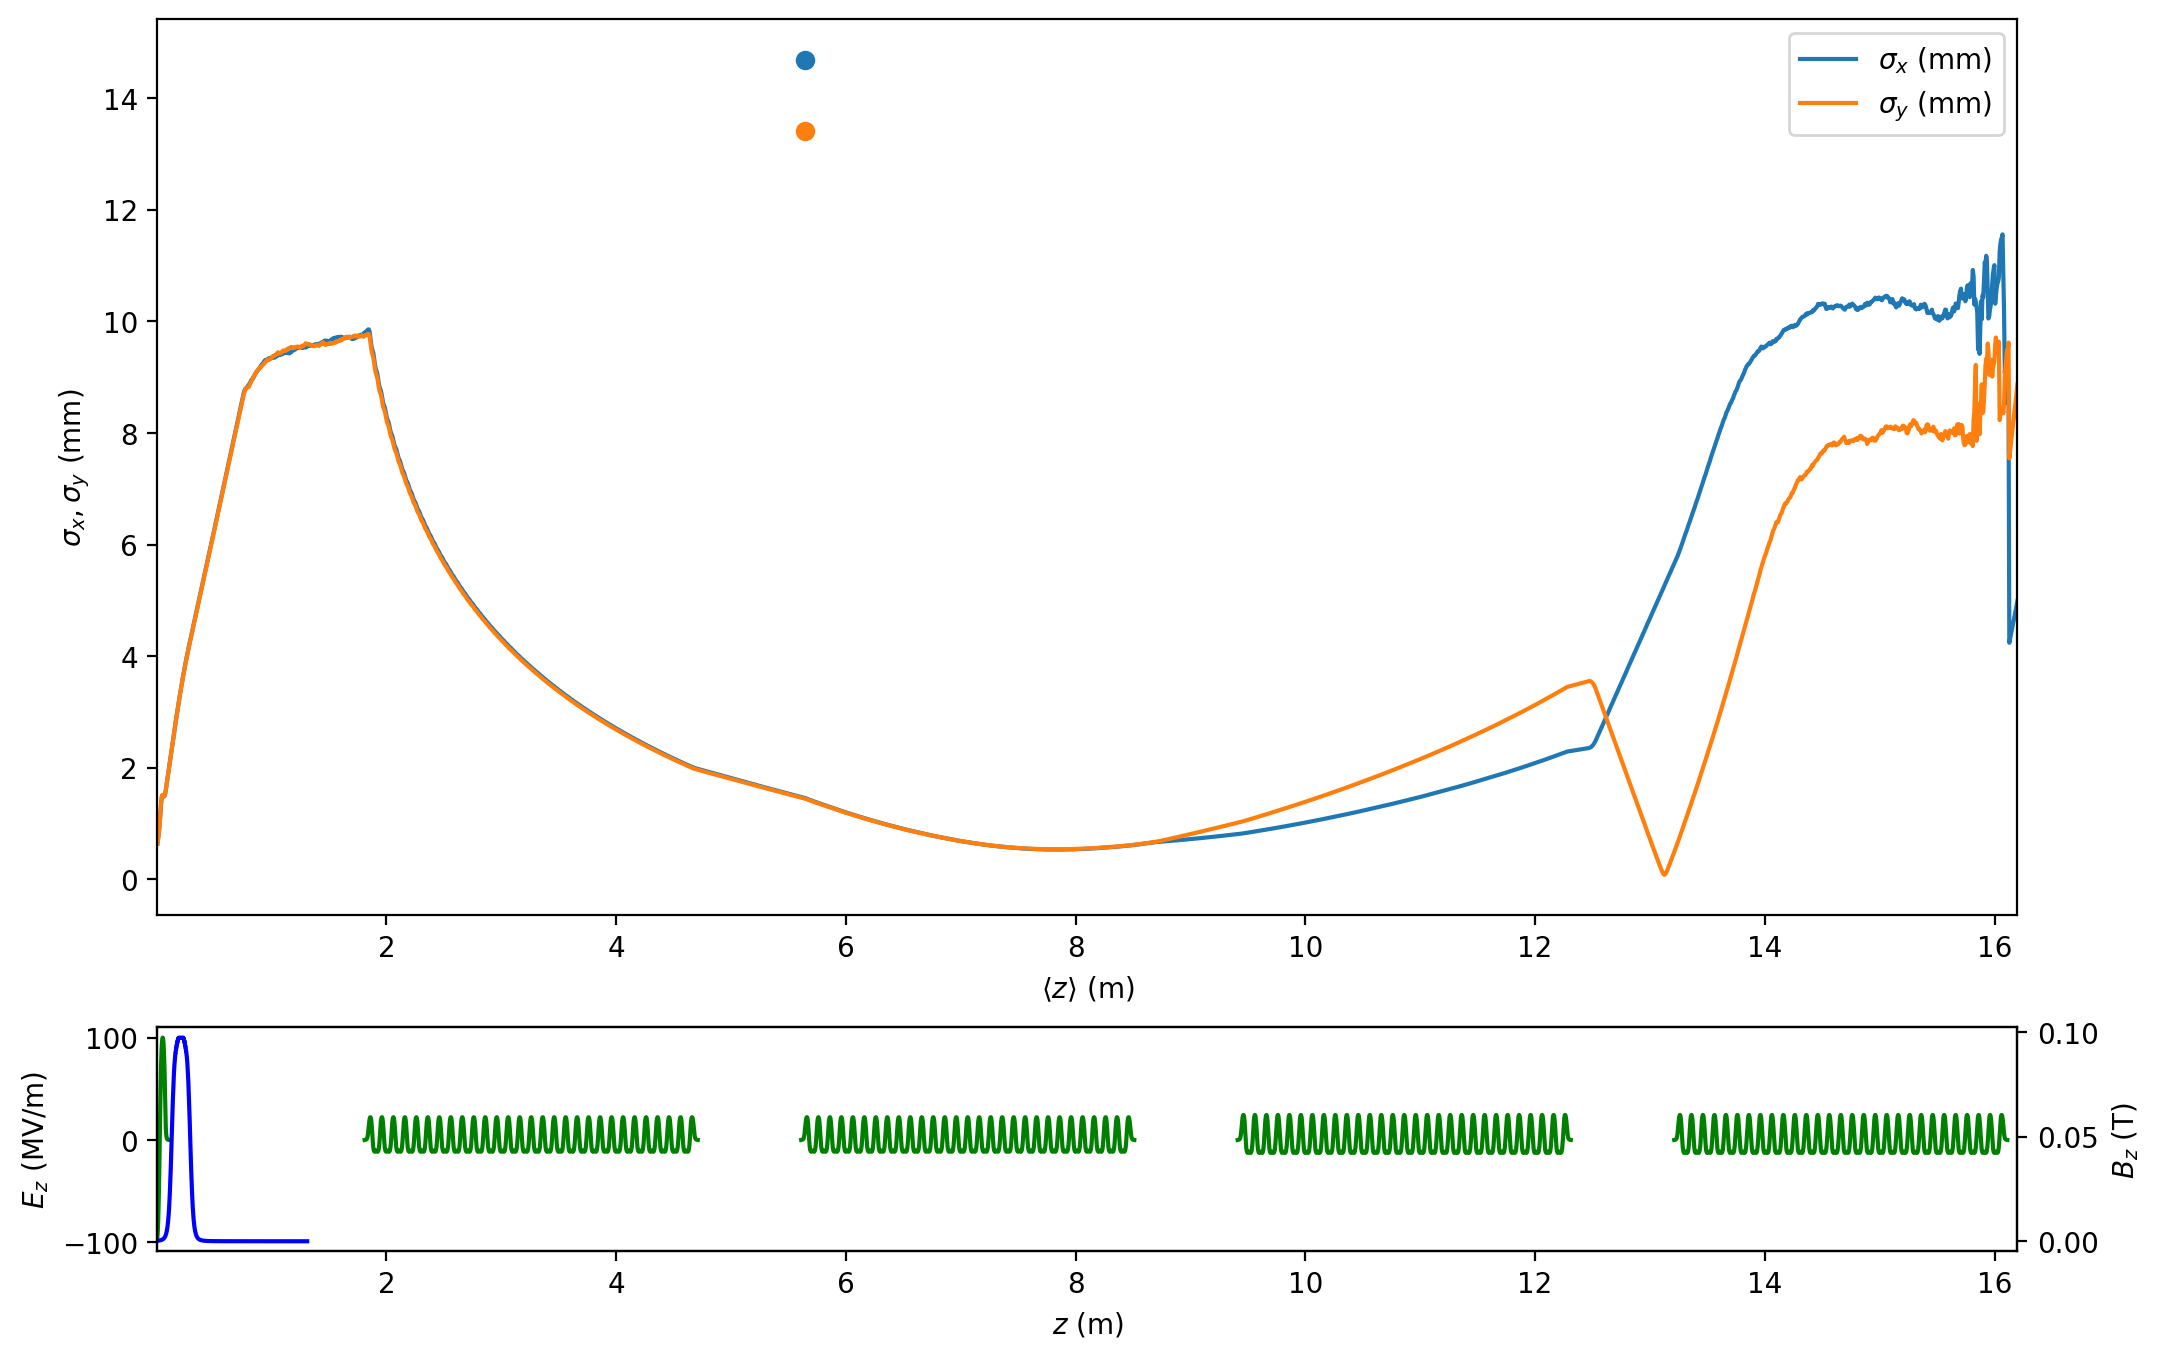

In [39]:
index = 0
for weights in weight_combinations[2:3]:
    print(f"Weights: {weights}, min_index: {min_indices[index]}")
    
    filename_weights = "_".join(map(lambda x: str(x).replace('.', 'p'), weights))
    pickle_filename = f'data/gp_minimize_result_{filename_weights}.pkl'
    
    with open(pickle_filename, 'rb') as f:
        result = pickle.load(f)
    
    parameters = result.x

    astra_sim = Astra('astra.in')
    astra_sim.timeout = None
    astra_sim.verbose = False

    print ("parameters:", parameters)
    # Set up Astra parameters by modifying the input file or setting the attributes in the object
    astra_sim['solenoid:maxb(1)'] = parameters[0]           # solenoid strength [T]
    astra_sim['quadrupole:q_grad(1)'] = parameters[1]        # quadrupole strength [1/m^2]
    astra_sim['quadrupole:q_grad(2)'] = parameters[2]        # quadrupole strength [1/m^2]
    astra_sim['cavity:phi(1)'] = parameters[3]              # RF gun cavity input phase [deg]
    astra_sim['cavity:phi(2)'] = parameters[4]              # ACC1 cavity input phase [deg]
    astra_sim['cavity:phi(3)'] = parameters[4]              # ACC2 cavity input phase [deg]
    astra_sim['cavity:phi(4)'] = parameters[5]              # ACC3 cavity input phase [deg]
    astra_sim['cavity:phi(5)'] = parameters[5]              # ACC4 cavity input phase [deg]

    # Run the Astra simulation
    astra_sim.run()
    print(astra_sim.output['stats'])

    # Extract results from the simulation
    norm_emit_x = astra_sim.output['stats']['norm_emit_x'][-1]
    norm_emit_y = astra_sim.output['stats']['norm_emit_y'][-1]
    sigma_energy = astra_sim.output['stats']['sigma_energy'][-1]

    sigma_z = astra_sim.output['stats']['sigma_z'][-1]
    mean_kinetic_energy = astra_sim.output['stats']['mean_kinetic_energy'][-1]

    print ("objectives:", norm_emit_x, norm_emit_y, sigma_energy, sigma_z, mean_kinetic_energy)

    #astra_sim.plot(['norm_emit_x', 'norm_emit_y'], y2='sigma_energy')
    #astra_sim.plot()
    plot_filename = f'img/astra_sim_{filename_weights}.png'
    astra_plot(astra_sim, plot_filename, beamsize=False)
    plot_filename = f'img/astra_sim2_{filename_weights}.png'
    astra_plot(astra_sim, plot_filename, beamsize=True)

    index += 1

{'mean_z': array([6.4275e-03, 1.2953e-02, 1.9440e-02, ..., 1.6181e+01, 1.6187e+01,
       1.6200e+01]), 'mean_t': array([3.9605e-11, 6.3275e-11, 8.5840e-11, ..., 5.4040e-08, 5.4062e-08,
       5.4105e-08]), 'mean_x': array([ 7.8727e-07,  5.3109e-07,  3.8200e-07, ..., -2.5644e-06,
       -2.5656e-06, -2.5681e-06]), 'sigma_x': array([0.00061596, 0.00071459, 0.00082923, ..., 0.0002779 , 0.00027808,
       0.00027846]), 'sigma_xp': array([1.6581e-02, 1.5424e-02, 2.0691e-02, ..., 4.2956e-05, 4.2957e-05,
       4.2958e-05]), 'norm_emit_x': array([2.9408e-06, 3.0047e-06, 3.0287e-06, ..., 3.4726e-06, 3.4727e-06,
       3.4728e-06]), 'cov_x__xp': array([1.00820333e-05, 1.09761024e-05, 1.71385256e-05, ...,
       8.02019400e-09, 8.03206272e-09, 8.05640472e-09]), 'mean_y': array([-8.8849e-07, -1.0778e-06, -1.2620e-06, ...,  5.3621e-06,
        5.3324e-06,  5.2731e-06]), 'sigma_y': array([0.00061619, 0.00071482, 0.00082947, ..., 0.00025169, 0.00024995,
       0.00024649]), 'sigma_yp': array([0.016

<Figure size 1500x800 with 0 Axes>

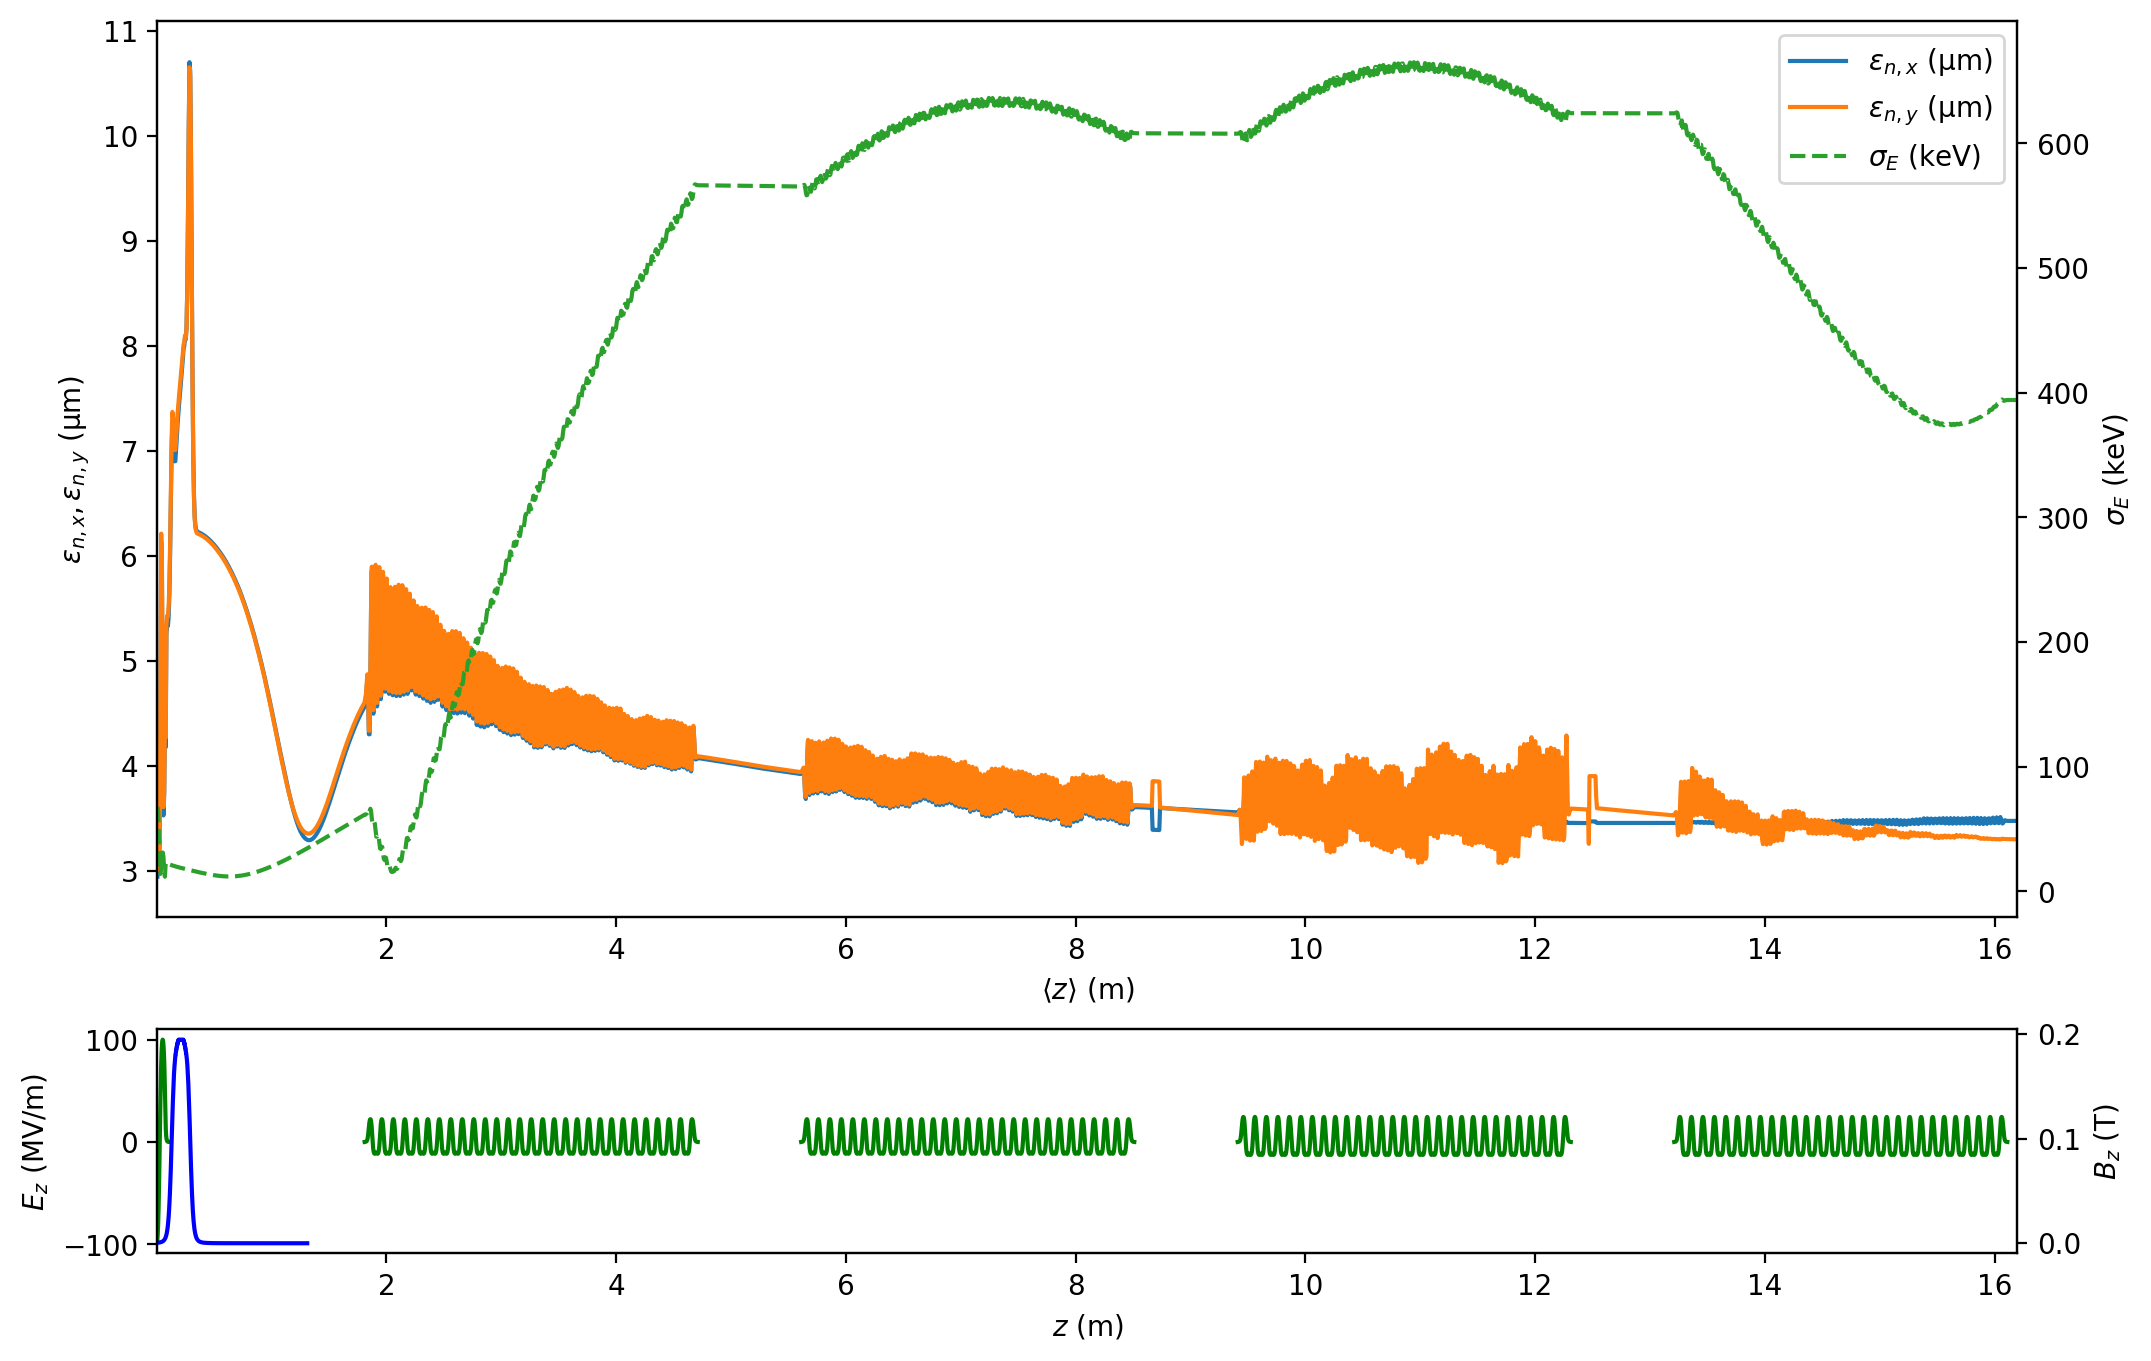

<Figure size 1500x800 with 0 Axes>

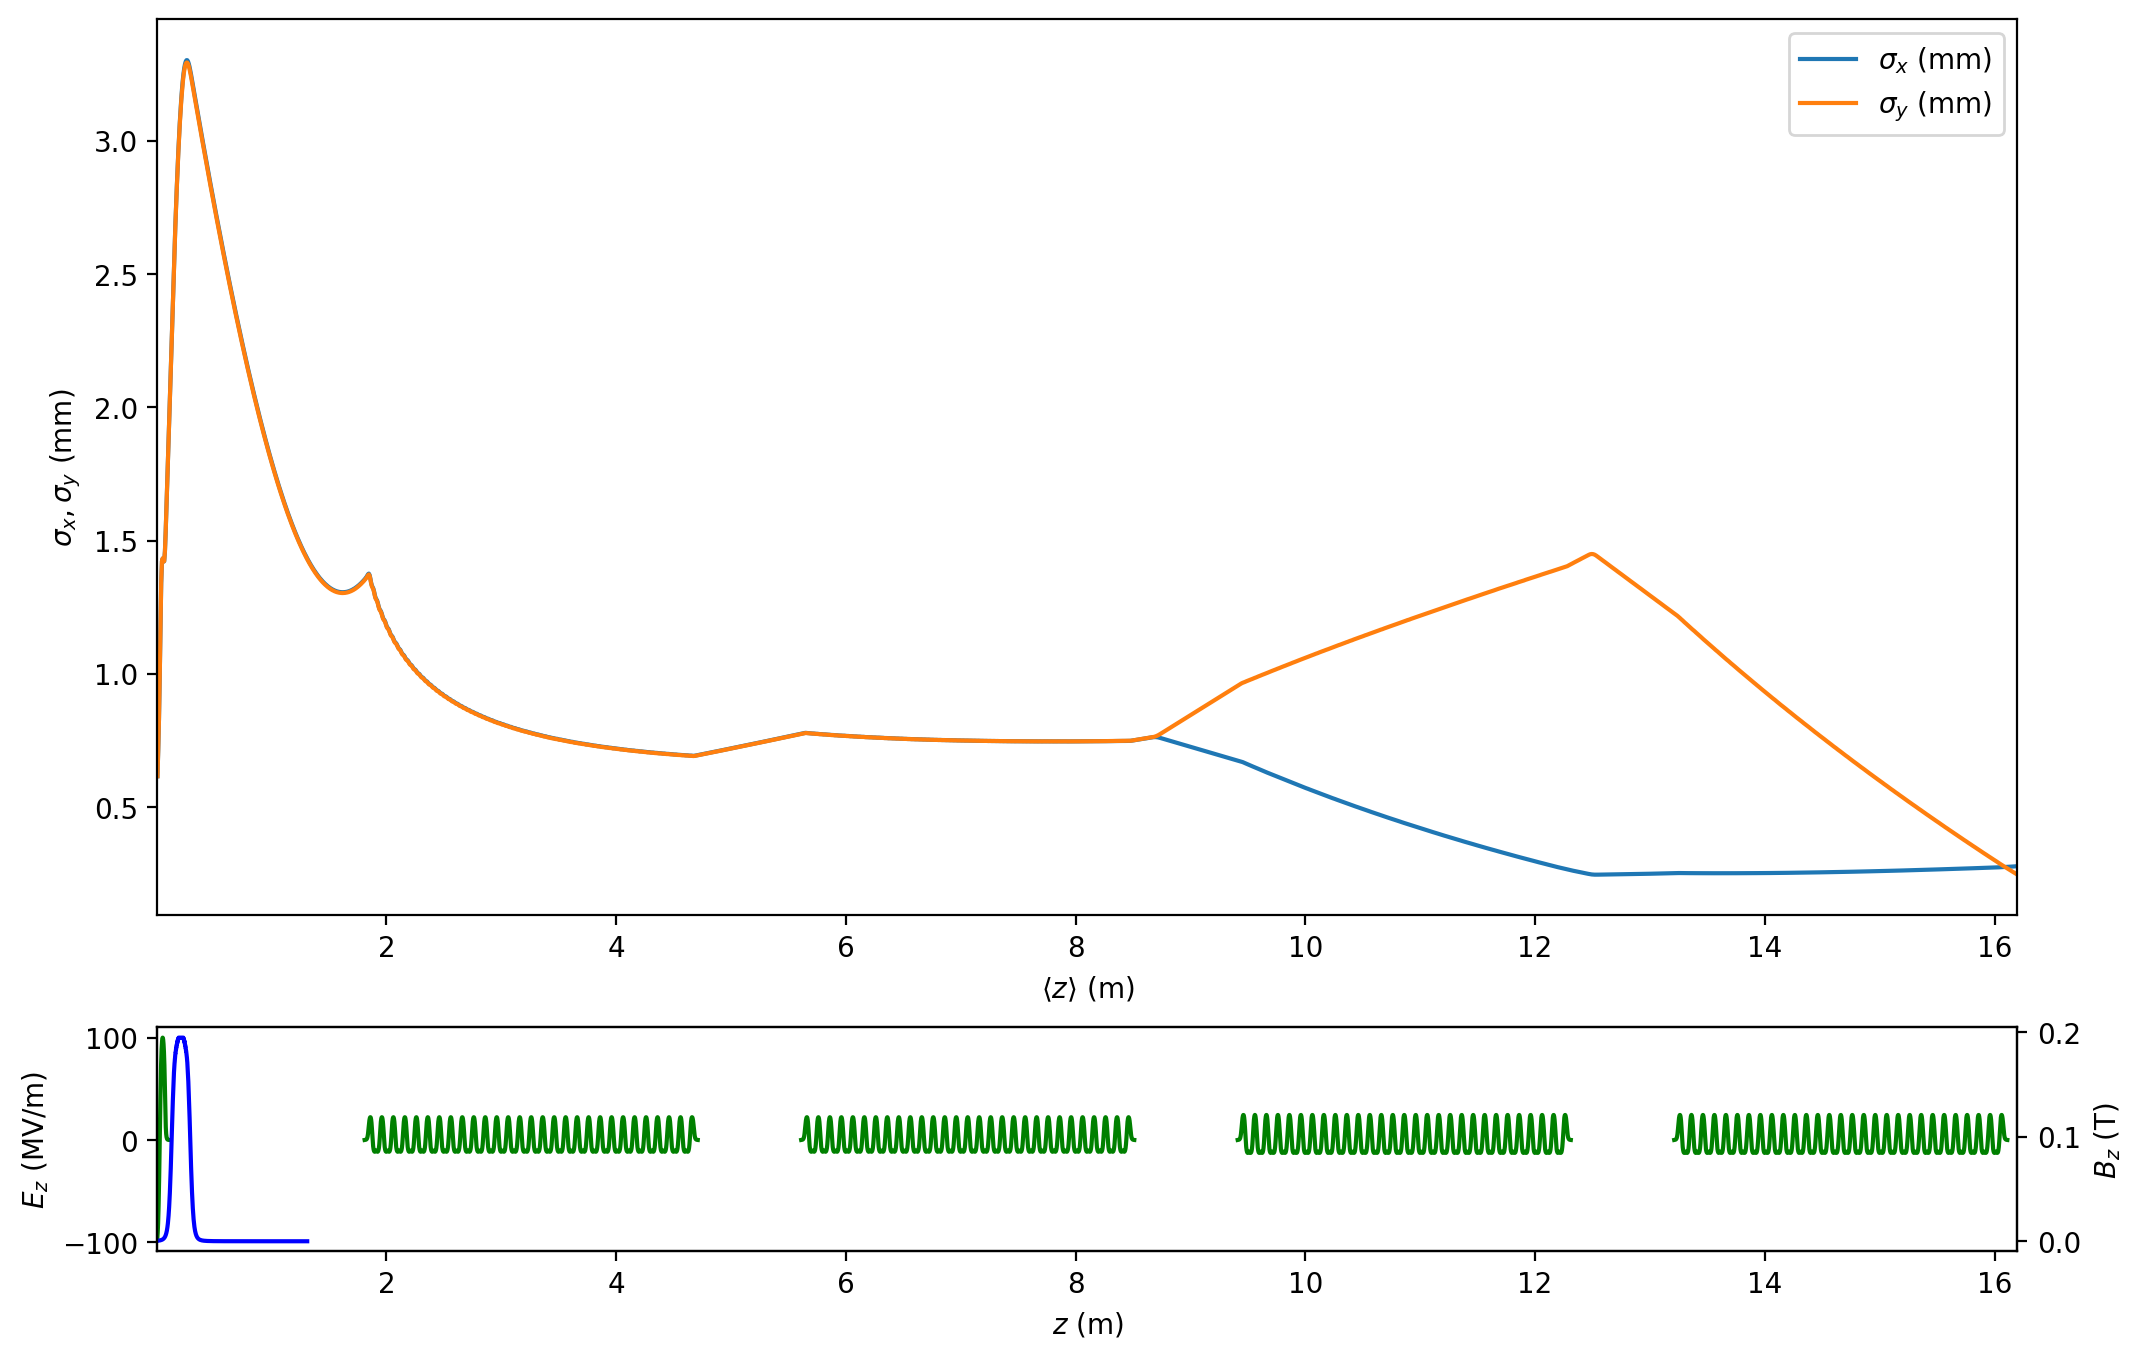

In [40]:
index = 0
for weights in weight_combinations[:1]:
    astra_sim = Astra('astra.in')
    astra_sim.timeout = None
    astra_sim.verbose = False

    # Run the Astra simulation
    astra_sim.run()

    print(astra_sim.output['stats'])

    # Extract results from the simulation
    norm_emit_x = astra_sim.output['stats']['norm_emit_x'][-1]
    norm_emit_y = astra_sim.output['stats']['norm_emit_y'][-1]
    sigma_energy = astra_sim.output['stats']['sigma_energy'][-1]

    sigma_z = astra_sim.output['stats']['sigma_z'][-1]
    mean_kinetic_energy = astra_sim.output['stats']['mean_kinetic_energy'][-1]

    print ("objectives:", norm_emit_x, norm_emit_y, sigma_energy, sigma_z, mean_kinetic_energy)

    #astra_sim.plot(['norm_emit_x', 'norm_emit_y'], y2='sigma_energy')
    #astra_sim.plot()
    plot_filename = f'img/astra_sim.png'
    astra_plot(astra_sim, plot_filename, beamsize=False)
    plot_filename = f'img/astra_sim2.png'
    astra_plot(astra_sim, plot_filename, beamsize=True)

    index += 1